## --- Quantitative Analysis ---

In [1]:
from evaluation.evaluation import evaluate_seed, summarize_datasets, summarize_proacts_multiple_datasets
from evaluation.evaluation import plot_paired_propagation_penalty_by_dataset, plot_propagation_penalty_outcome_by_trace_length
from evaluation.evaluation import plot_loss_vs_propagation_penalty_by_dataset, plot_loss_vs_propagation_penalty_single_method
from evaluation.evaluation import generate_proacts_multiple_position_plots, plot_proacts_multiple_metric_heatmap, plot_proacts_multiple_margin_vs_propagation
from evaluation.evaluation import runtime_table_all_seeds
from evaluation.evaluation import propagation_prevalence_summary, summarize_proacts_propagation_ablation

In [2]:
datasets = [
    "bpic12",
    "bpic17",
    "bpic19",
    "bpic20_Int",
    "bpic20_Dom",
    "bpic20_Ptc",
    "bpic20_Rfp",
    "road_fine",
    "sepsis",
    "hospital_billing",
]

seeds = [
    42,
    13,
    777,
]


all_results = {}

for dataset in datasets:

    all_results[
        dataset
    ] = {}

    for seed in seeds:

        proacts_path = (
            f"{dataset}/"
            f"seed_experiments/"
            f"generated_experiments_results/"
            f"GA_single_desired_seed{seed}_"
            f"experiment_results.xlsx"
        )

        dice_path = (
            f"{dataset}/"
            f"dice4el/"
            f"seed_experiments/"
            f"generated_experiments_results/"
            f"DiCE4EL_seed{seed}_"
            f"experiment_results.xlsx"
        )

        dice4el_plus_path = (
            f"{dataset}/"
            f"dice4el/"
            f"seed_experiments/"
            f"generated_experiments_results/"
            f"DiCE4EL-Optimized_seed{seed}_"
            f"experiment_results.xlsx"
        )

        proacts_multiple_path = (
            f"{dataset}/"
            f"seed_experiments/"
            f"generated_experiments_results/"
            f"GA_multiple_desired_seed{seed}_"
            f"experiment_results.xlsx"
        )

        all_results[
            dataset
        ][seed] = evaluate_seed(
            proacts_path=proacts_path,
            dice_path=dice_path,
            dice4el_plus_path=(
                dice4el_plus_path
            ),
            proacts_multiple_path=(
                proacts_multiple_path
            ),
        )

In [3]:
# ============================================================
# Single desired position summary
# ============================================================

single_summary = summarize_datasets(
    all_dataset_results=(
        all_results
    ),
    output_path=(
        "summary_evaluation/"
        "all_datasets_results.xlsx"
    ),
    alpha=0.001,
    tolerance=1e-8,
    practical_effect_threshold=0.50,

    # Main trace-length comparison.
    trace_length_baseline=(
        "DiCE4EL+"
    ),

    trace_length_condition=(
        "Flip Success"
    ),

    # Set explicitly if your actual column has another name.
    # Example:
    # trace_length_column="trace_length",
    trace_length_column=None,
)

In [4]:
# ============================================================
# Multiple desired position summary
# ============================================================

multiple_summary = (
    summarize_proacts_multiple_datasets(
        all_dataset_results=(
            all_results
        ),
        output_path=(
            "summary_evaluation/"
            "proacts_multiple_positions.xlsx"
        ),
        tolerance=1e-8,
    )
)


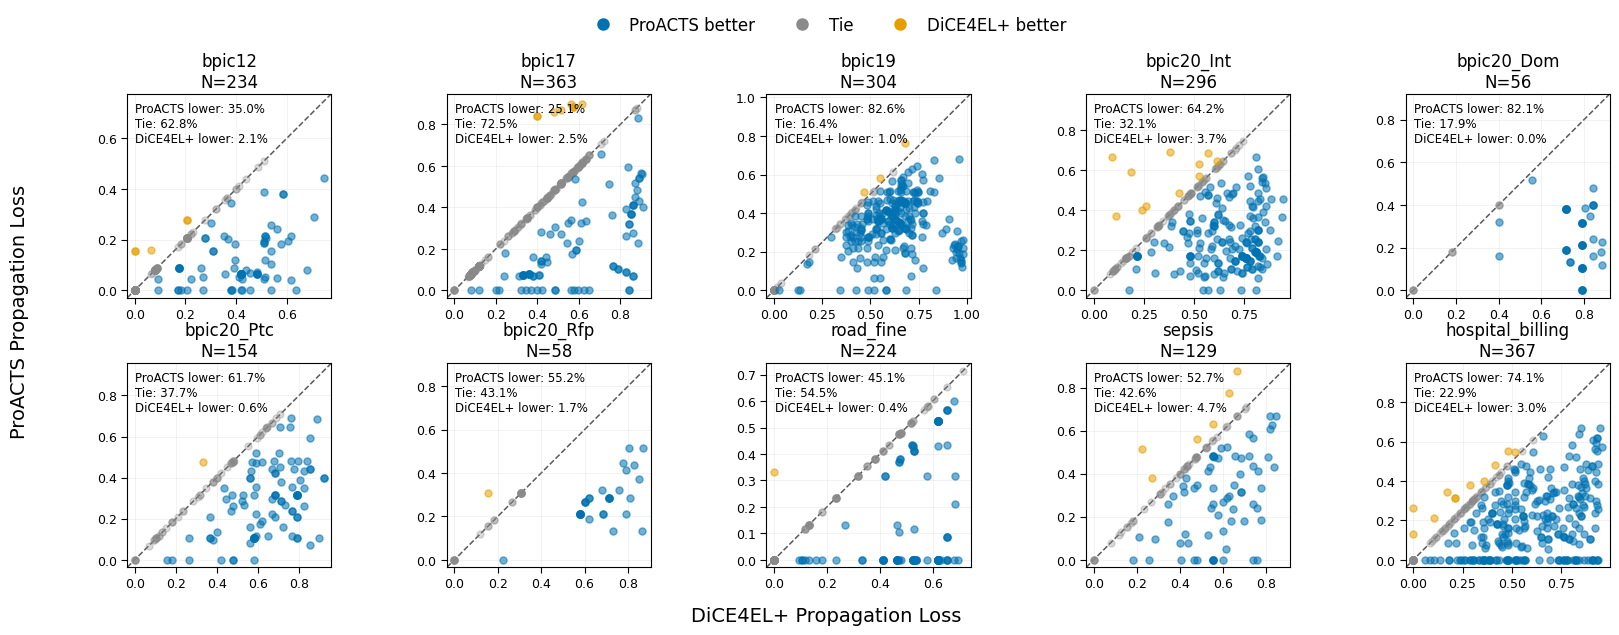

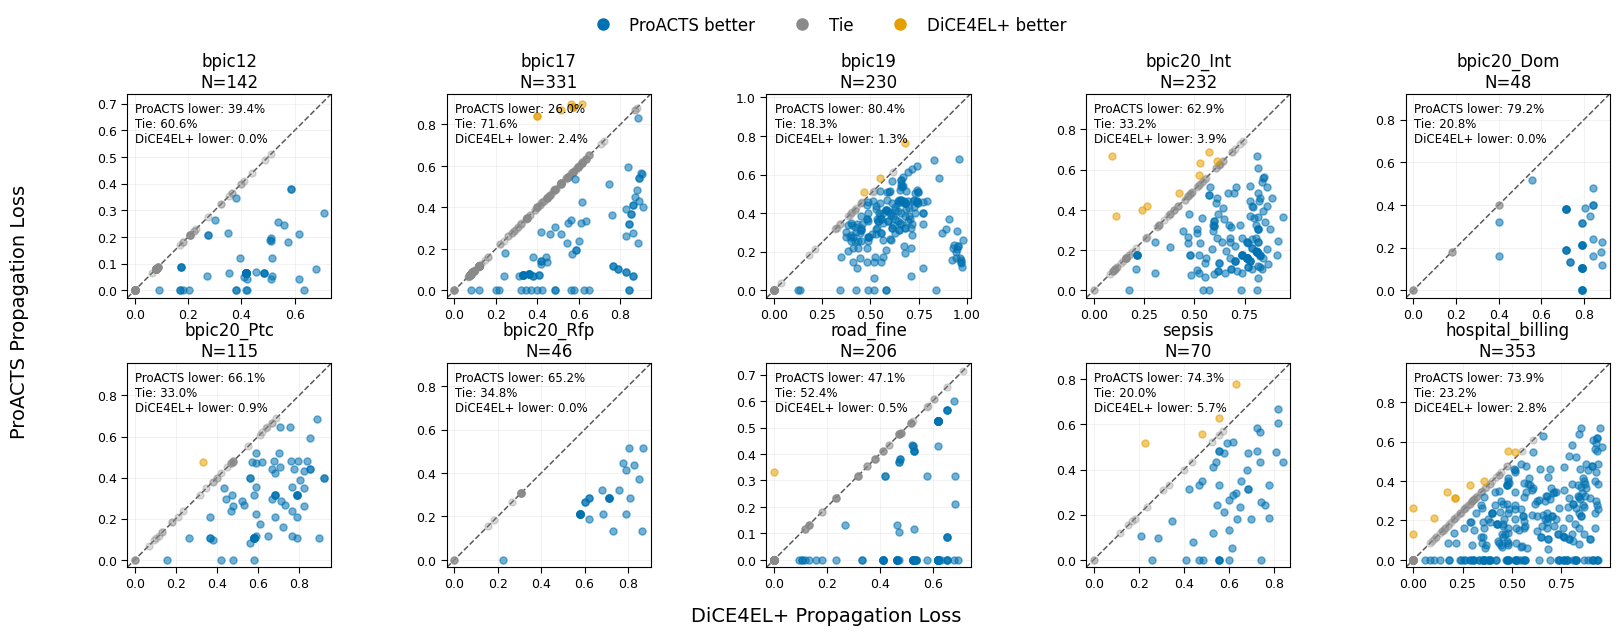

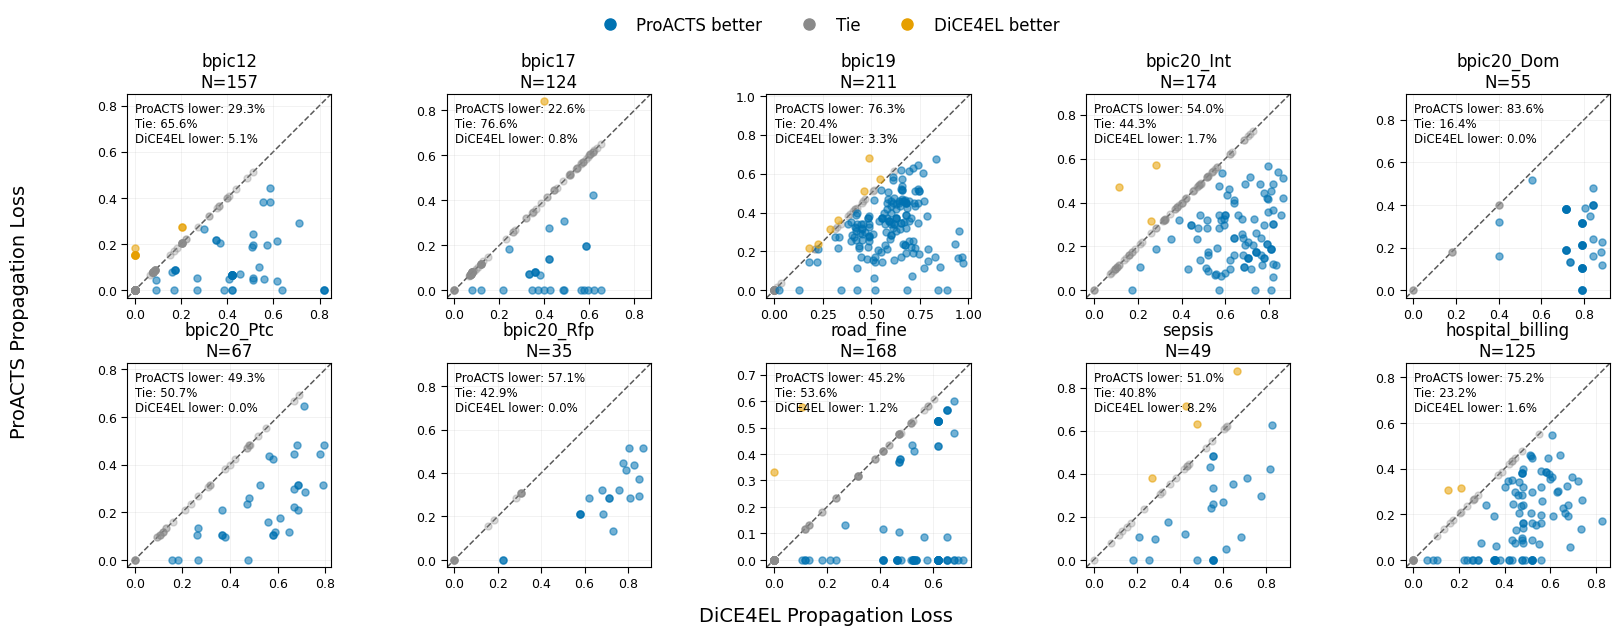

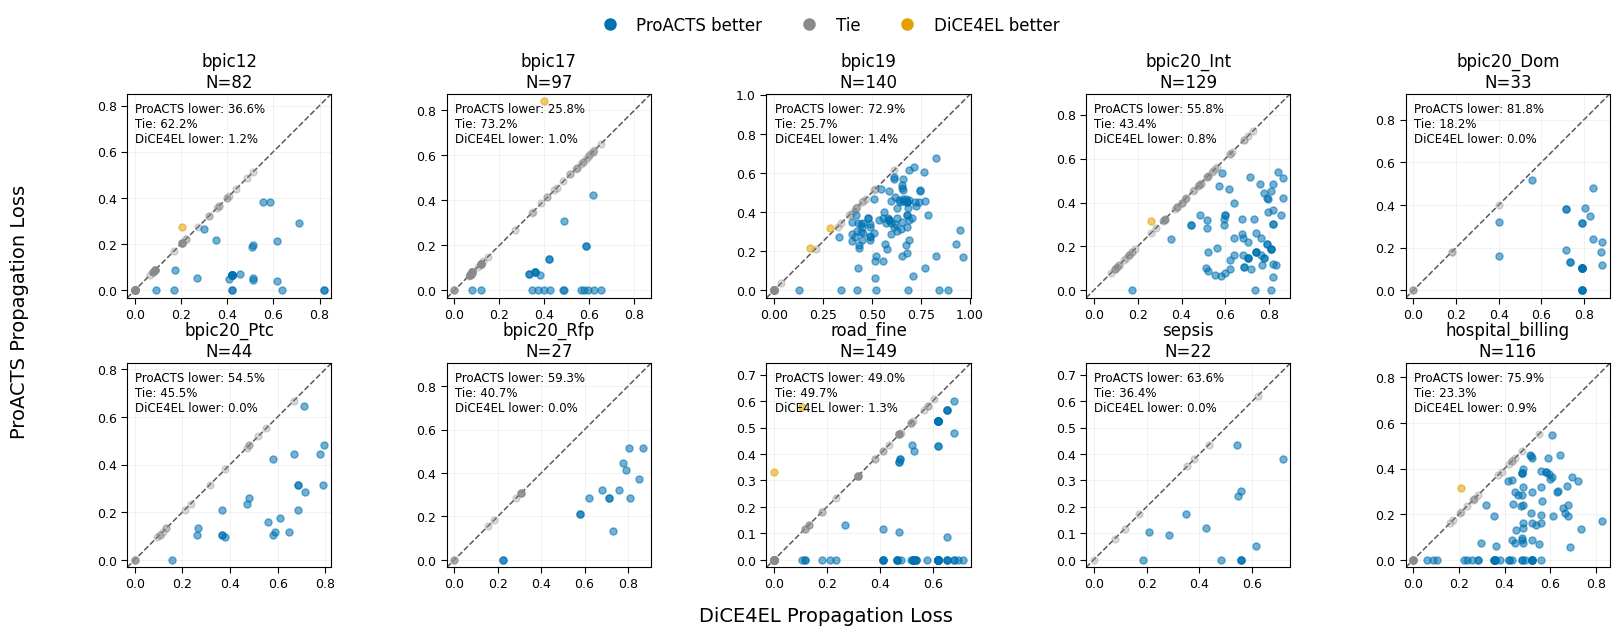

In [5]:
# ============================================================
# Plots
# 10 datasets => 2 rows x 5 columns
# ============================================================

# Flip success
paired_pv_summary = (
    plot_paired_propagation_penalty_by_dataset(
        all_results,
        baseline_method="DiCE4EL+",
        condition="Flip Success",
        tolerance=1e-8,
        output_path=(
            "summary_evaluation/"
            "paired_propagation_penalty_flip_dice4el_plus.pdf"
        ),
        show=True,
    )
)

# Margin success
paired_pv_summary = (
    plot_paired_propagation_penalty_by_dataset(
        all_results,
        baseline_method="DiCE4EL+",
        condition="Margin Success",
        tolerance=1e-8,
        output_path=(
            "summary_evaluation/"
            "paired_propagation_penalty_margin_dice4el_plus.pdf"
        ),
        show=True,
    )
)

# Flip success
paired_pv_summary = (
    plot_paired_propagation_penalty_by_dataset(
        all_results,
        baseline_method="DiCE4EL",
        condition="Flip Success",
        tolerance=1e-8,
        output_path=(
            "summary_evaluation/"
            "paired_propagation_penalty_flip_dice4el.pdf"
        ),
        show=True,
    )
)

# Margin success
paired_pv_summary = (
    plot_paired_propagation_penalty_by_dataset(
        all_results,
        baseline_method="DiCE4EL",
        condition="Margin Success",
        tolerance=1e-8,
        output_path=(
            "summary_evaluation/"
            "paired_propagation_penalty_margin_dice4el.pdf"
        ),
        show=True,
    )
)

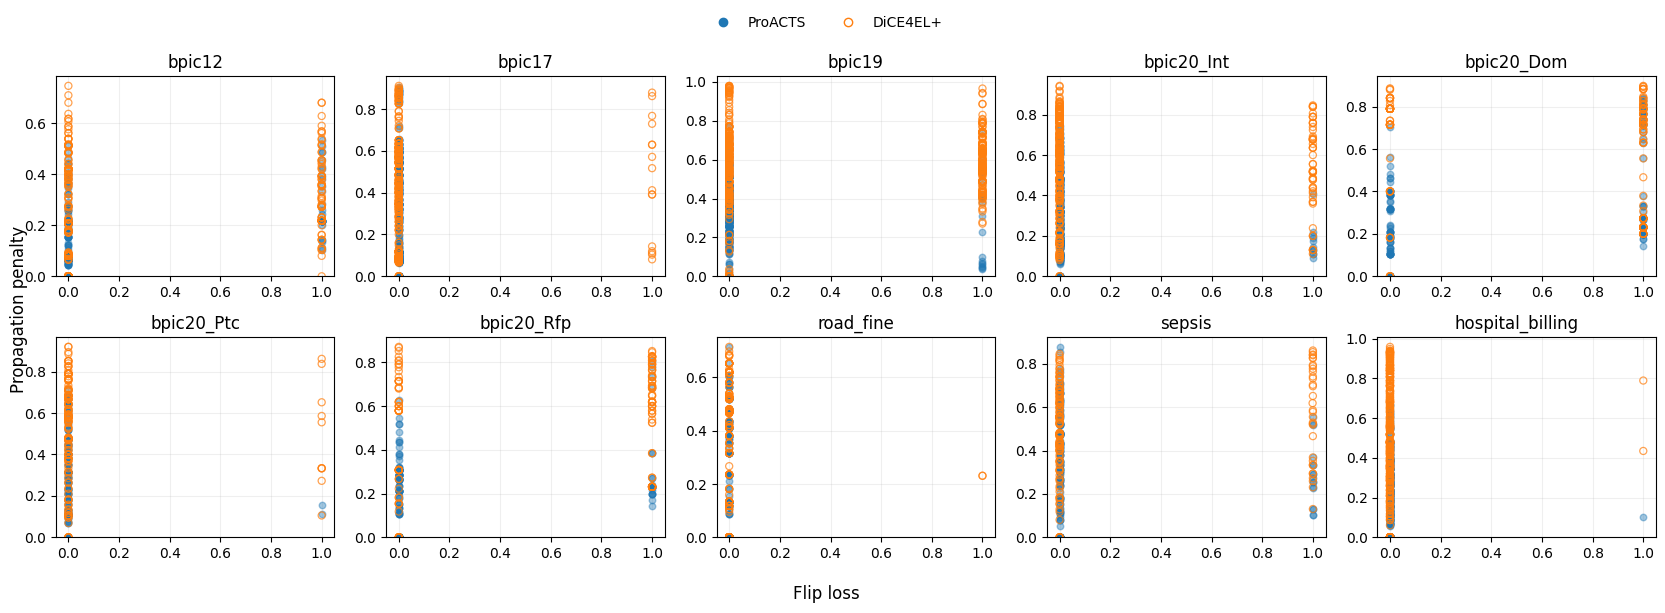

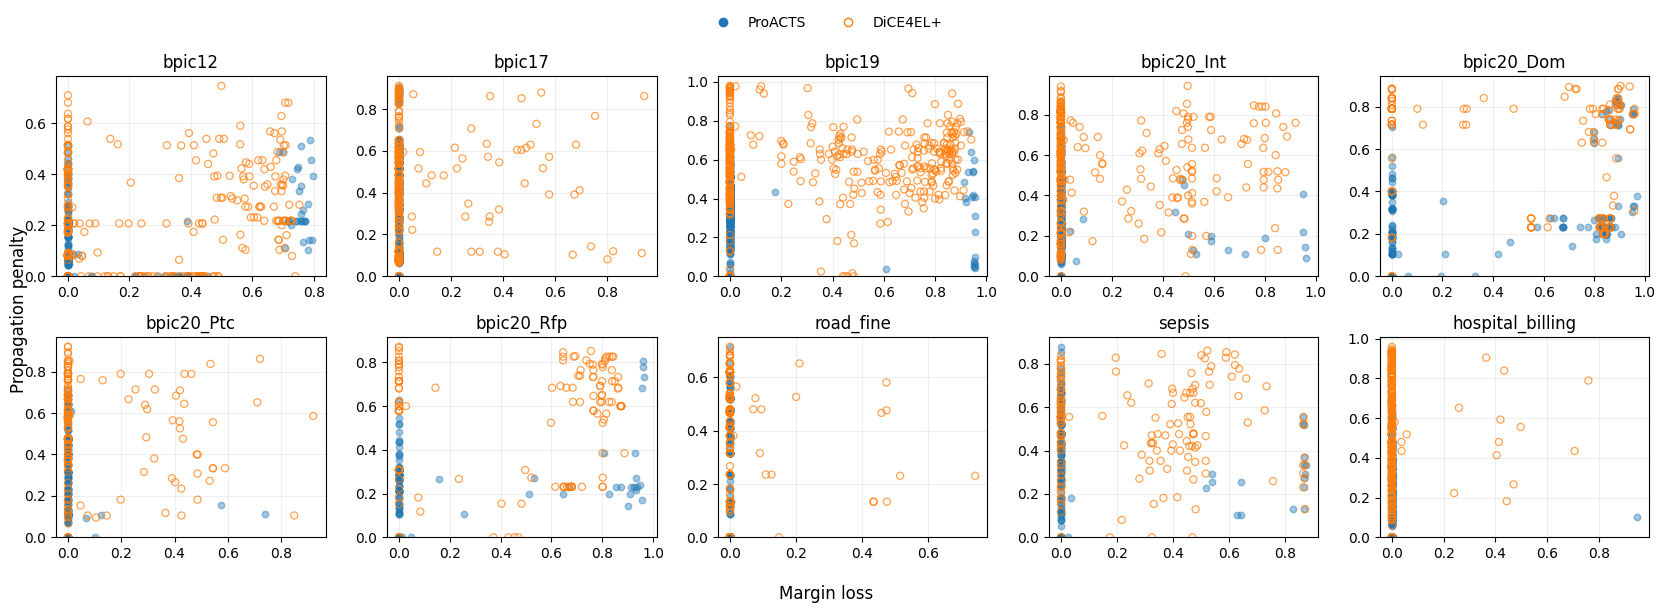

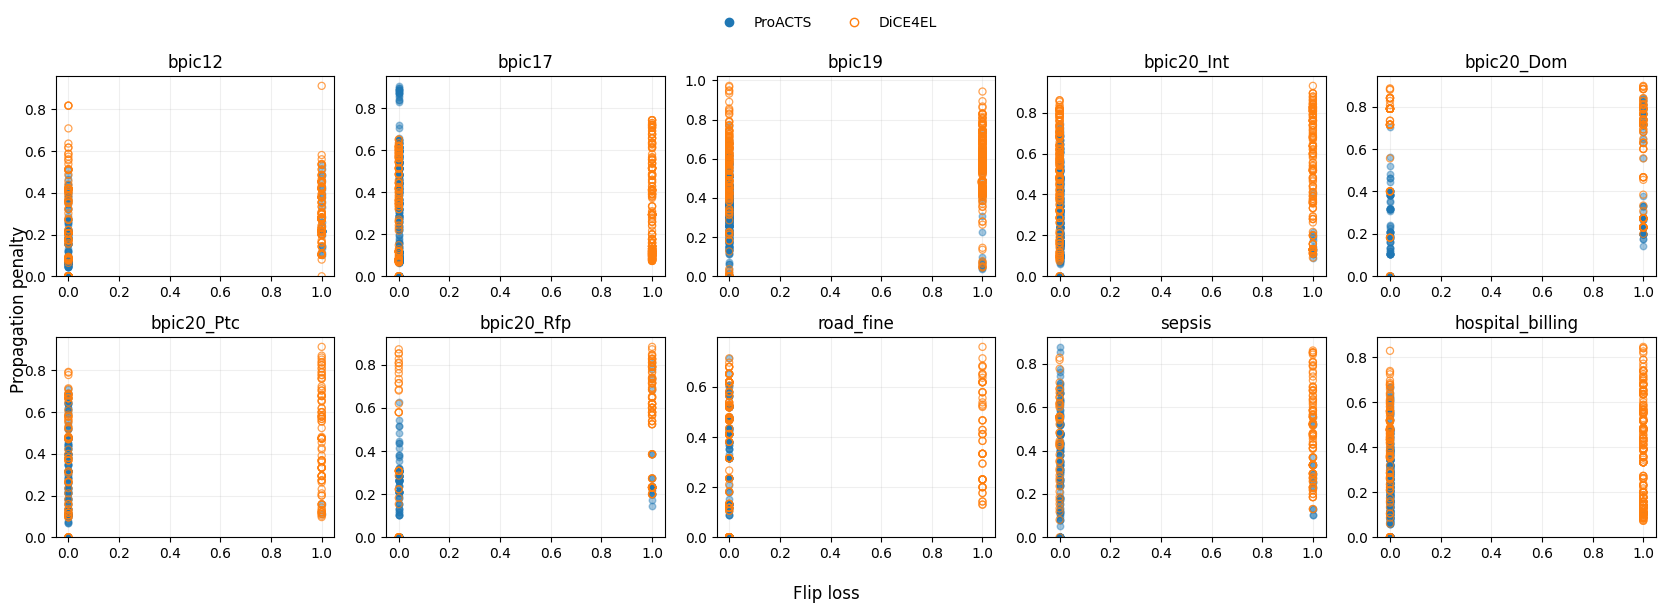

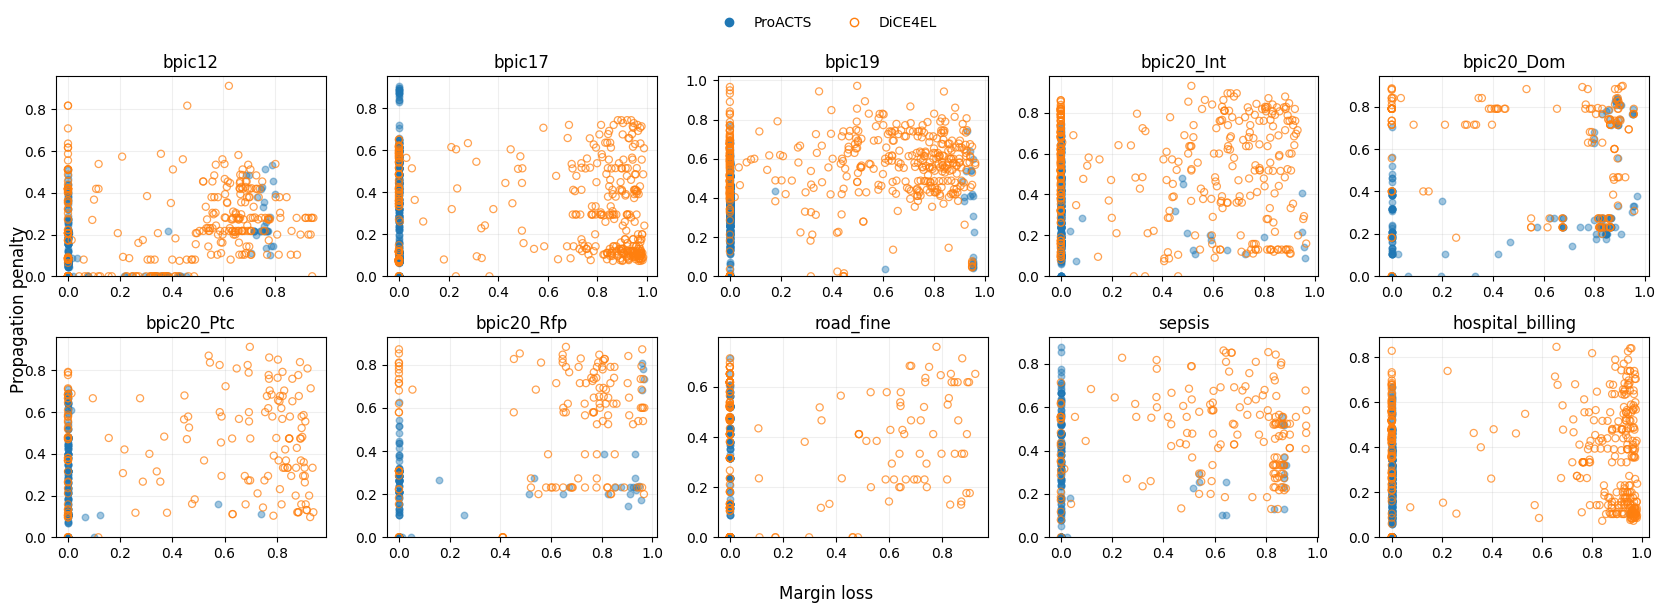

,Dataset,Loss,Baseline,ProACTS N,DiCE4EL N,ProACTS Median Loss,ProACTS Median Propagation Penalty,DiCE4EL Median Loss,DiCE4EL Median Propagation Penalty
0,bpic12,Margin Loss,DiCE4EL,312,312,0.000000,0.080000,0.495528,0.217391
1,bpic17,Margin Loss,DiCE4EL,379,379,0.000000,0.320000,0.838256,0.270270
2,bpic19,Margin Loss,DiCE4EL,467,467,0.000000,0.342857,0.564433,0.574468
3,bpic20_Int,Margin Loss,DiCE4EL,352,352,0.000000,0.259467,0.501856,0.555556
4,bpic20_Dom,Margin Loss,DiCE4EL,152,152,0.375454,0.233032,0.790675,0.714286
5,bpic20_Ptc,Margin Loss,DiCE4EL,166,166,0.000000,0.311741,0.679034,0.473684
6,bpic20_Rfp,Margin Loss,DiCE4EL,135,135,0.000000,0.230769,0.734340,0.600000
7,road_fine,Margin Loss,DiCE4EL,226,226,0.000000,0.000000,0.000000,0.411765
8,sepsis,Margin Loss,DiCE4EL,167,167,0.000000,0.352941,0.676065,0.515152
9,hospital_billing,Margin Loss,DiCE4EL,370,370,0.000000,0.186147,0.873183,0.393939


In [6]:
plot_loss_vs_propagation_penalty_by_dataset(
    all_results,
    baseline_method="DiCE4EL+",
    loss_metric="Flip Loss",
    output_path=(
        "summary_evaluation/"
        "flip_loss_vs_propagation_penalty_dice4el_plus.pdf"
    ),
)

plot_loss_vs_propagation_penalty_by_dataset(
    all_results,
    baseline_method="DiCE4EL+",
    loss_metric="Margin Loss",
    output_path=(
        "summary_evaluation/"
        "margin_loss_vs_propagation_penalty_dice4el_plus.pdf"
    ),
)

plot_loss_vs_propagation_penalty_by_dataset(
    all_results,
    baseline_method="DiCE4EL",
    loss_metric="Flip Loss",
    output_path=(
        "summary_evaluation/"
        "flip_loss_vs_propagation_penalty_dice4el.pdf"
    ),
)

plot_loss_vs_propagation_penalty_by_dataset(
    all_results,
    baseline_method="DiCE4EL",
    loss_metric="Margin Loss",
    output_path=(
        "summary_evaluation/"
        "margin_loss_vs_propagation_penalty_dice4el.pdf"
    ),
)

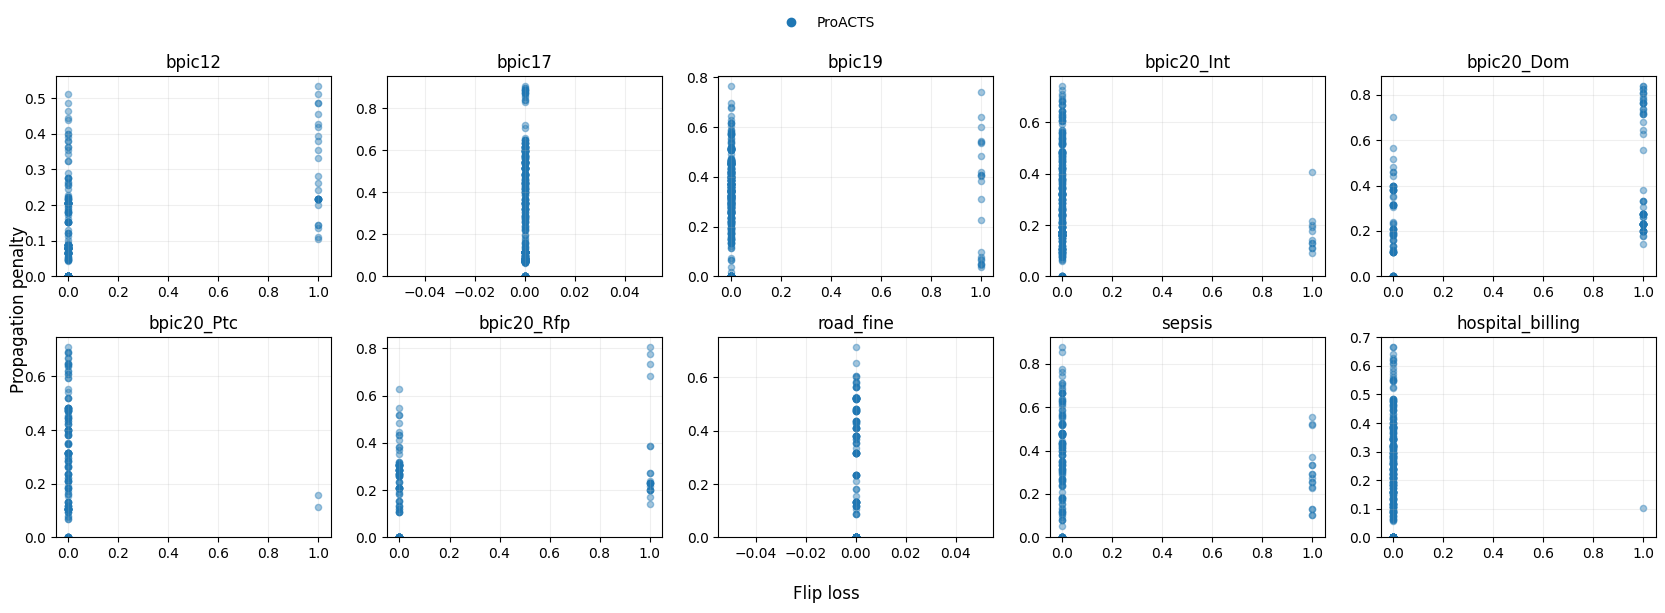

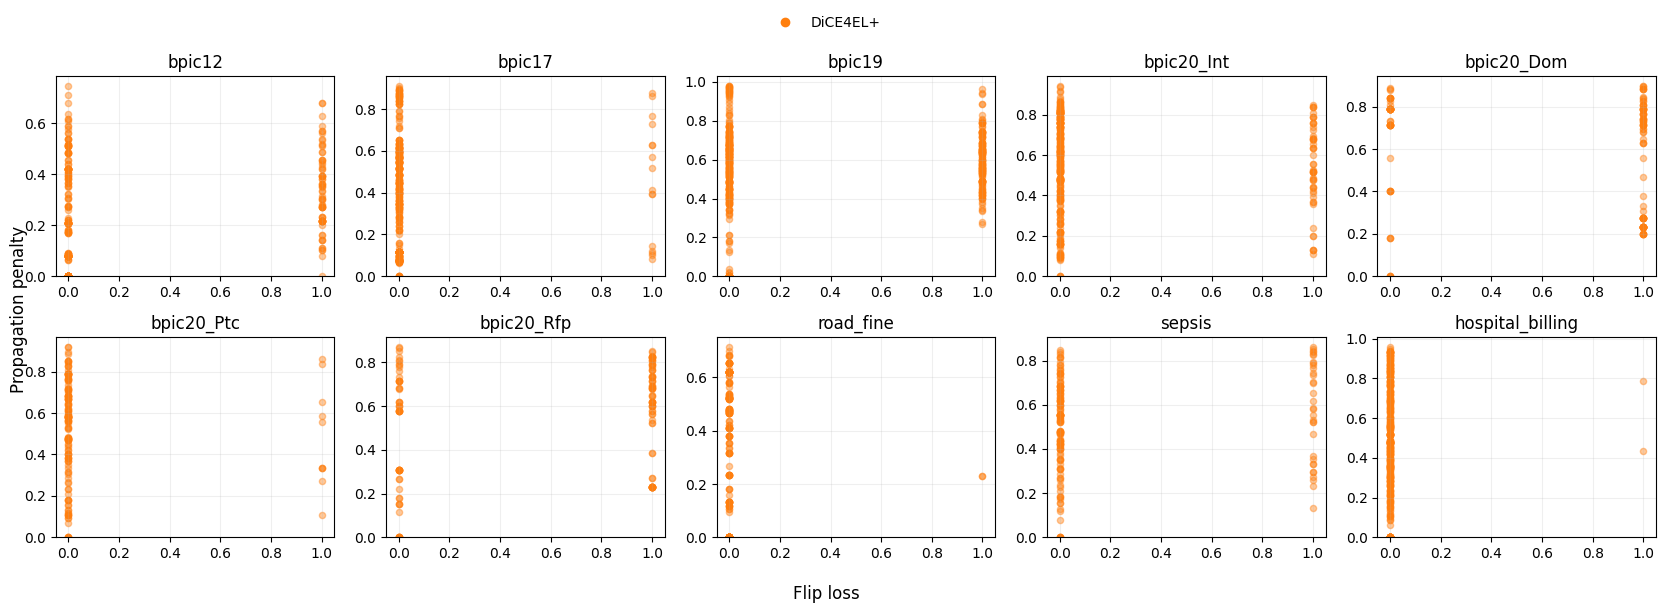

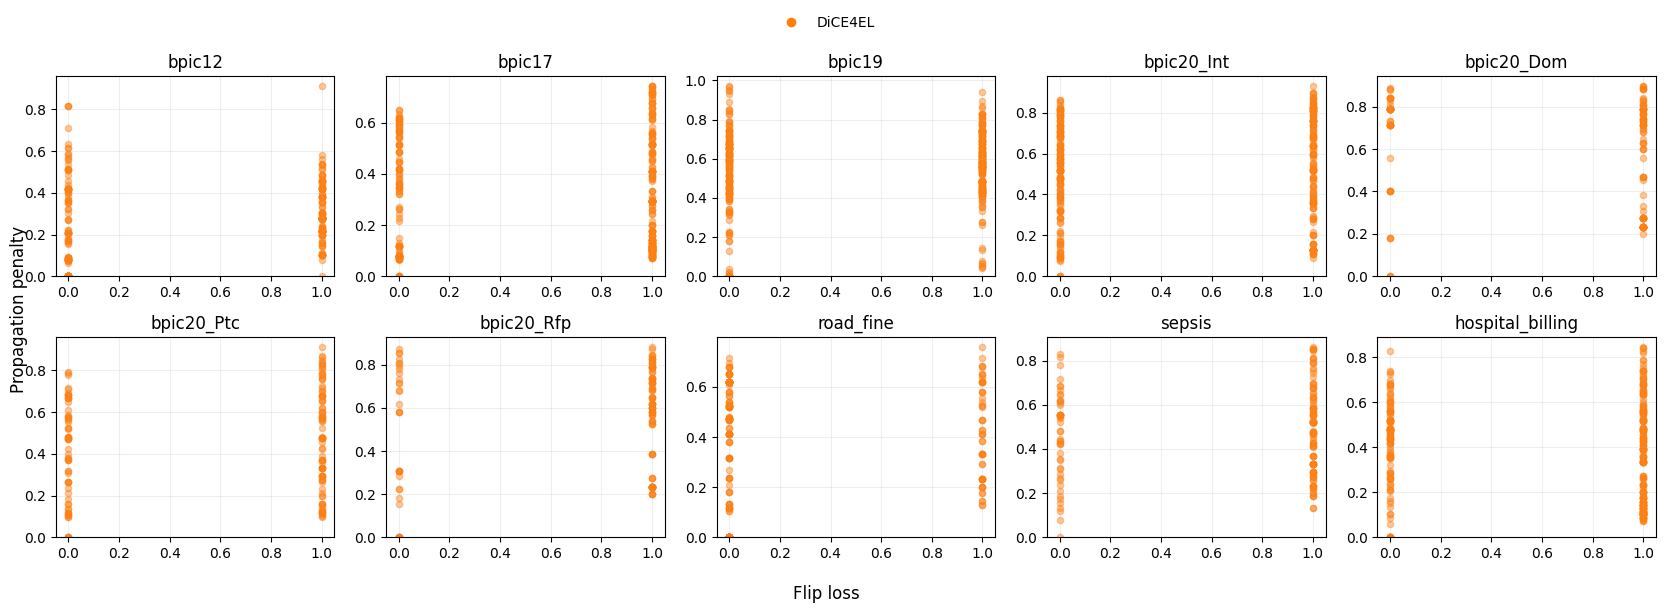

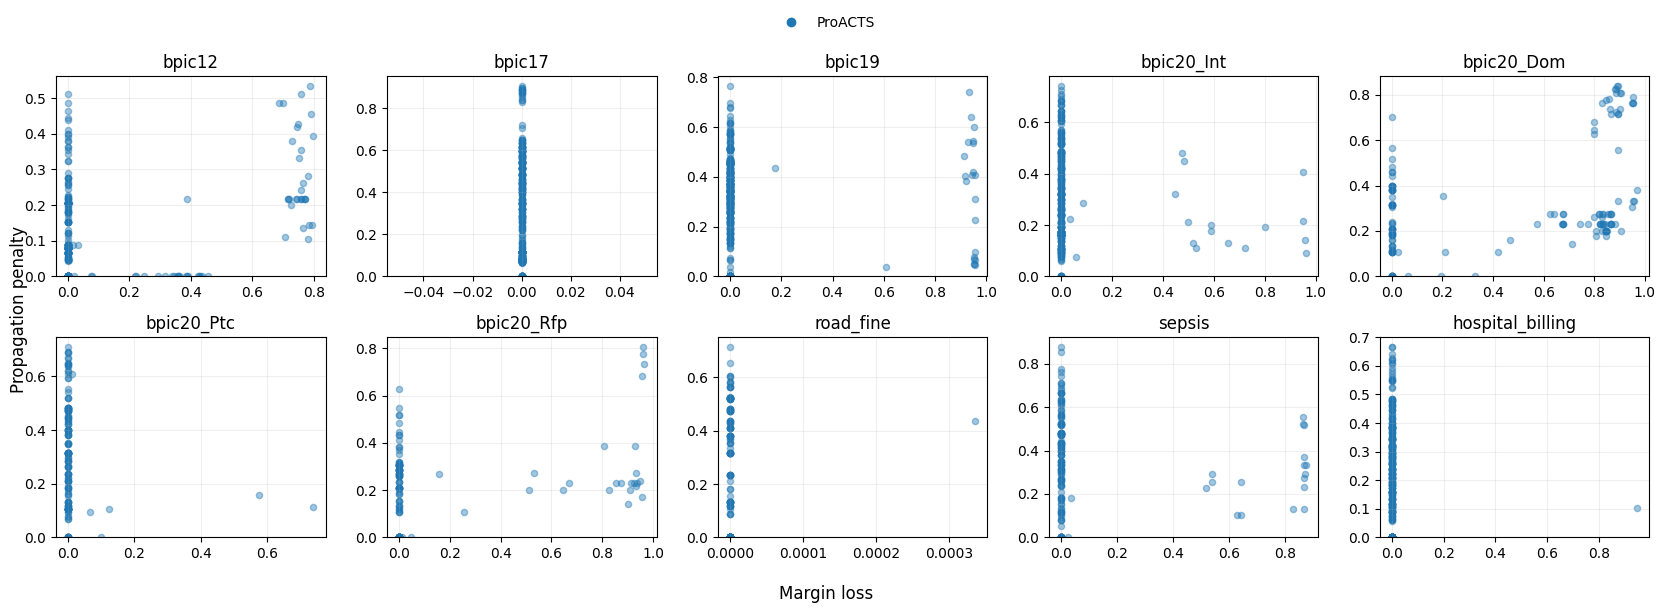

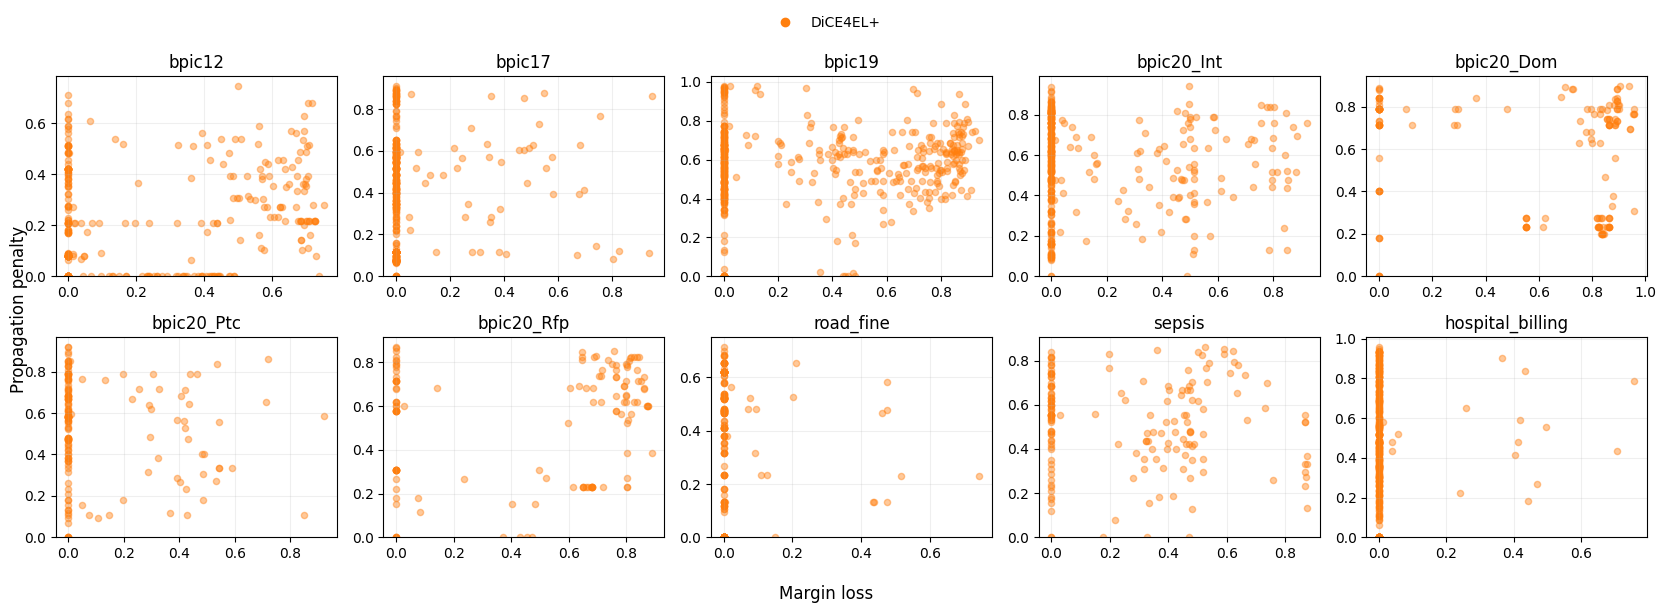

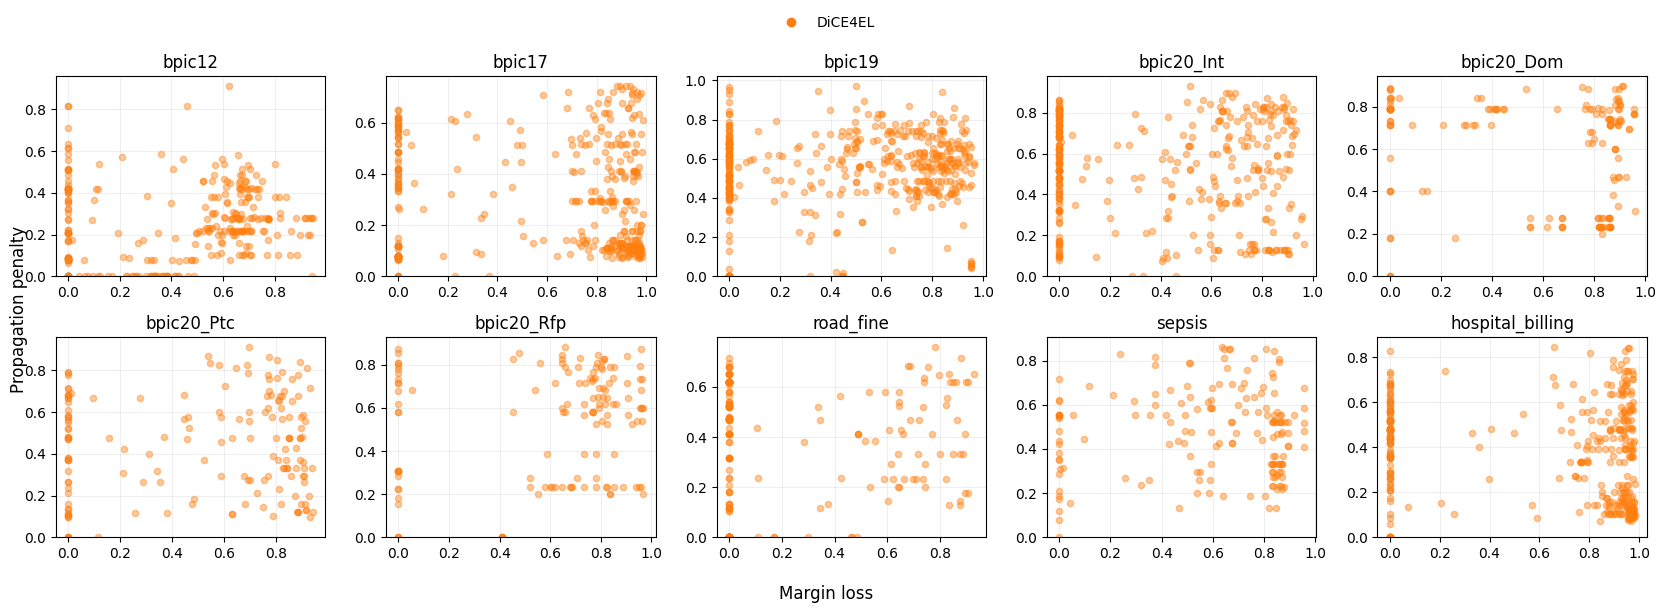

,Dataset,Method,Loss,N,Median Loss,Median Propagation Penalty
0,bpic12,DiCE4EL,Margin Loss,312,0.495528,0.217391
1,bpic17,DiCE4EL,Margin Loss,379,0.838256,0.270270
2,bpic19,DiCE4EL,Margin Loss,467,0.564433,0.574468
3,bpic20_Int,DiCE4EL,Margin Loss,352,0.501856,0.555556
4,bpic20_Dom,DiCE4EL,Margin Loss,152,0.790675,0.714286
5,bpic20_Ptc,DiCE4EL,Margin Loss,166,0.679034,0.473684
6,bpic20_Rfp,DiCE4EL,Margin Loss,135,0.734340,0.600000
7,road_fine,DiCE4EL,Margin Loss,226,0.000000,0.411765
8,sepsis,DiCE4EL,Margin Loss,167,0.676065,0.515152
9,hospital_billing,DiCE4EL,Margin Loss,370,0.873183,0.393939


In [7]:
plot_loss_vs_propagation_penalty_single_method(
    all_results,
    method="ProACTS",
    loss_metric="Flip Loss",
    output_path=(
        "summary_evaluation/"
        "proacts_flip_loss_vs_propagation_penalty.pdf"
    ),
    show=True,
)

plot_loss_vs_propagation_penalty_single_method(
    all_results,
    method="DiCE4EL+",
    loss_metric="Flip Loss",
    output_path=(
        "summary_evaluation/"
        "dice4el_plus_flip_loss_vs_propagation_penalty.pdf"
    ),
    show=True,
)

plot_loss_vs_propagation_penalty_single_method(
    all_results,
    method="DiCE4EL",
    loss_metric="Flip Loss",
    output_path=(
        "summary_evaluation/"
        "dice4el_flip_loss_vs_propagation_penalty.pdf"
    ),
    show=True,
)

plot_loss_vs_propagation_penalty_single_method(
    all_results,
    method="ProACTS",
    loss_metric="Margin Loss",
    output_path=(
        "summary_evaluation/"
        "proacts_margin_loss_vs_propagation_penalty.pdf"
    ),
    show=True,
)

plot_loss_vs_propagation_penalty_single_method(
    all_results,
    method="DiCE4EL+",
    loss_metric="Margin Loss",
    output_path=(
        "summary_evaluation/"
        "dice4el_plus_margin_loss_vs_propagation_penalty.pdf"
    ),
    show=True,
)

plot_loss_vs_propagation_penalty_single_method(
    all_results,
    method="DiCE4EL",
    loss_metric="Margin Loss",
    output_path=(
        "summary_evaluation/"
        "dice4el_margin_loss_vs_propagation_penalty.pdf"
    ),
    show=True,
)

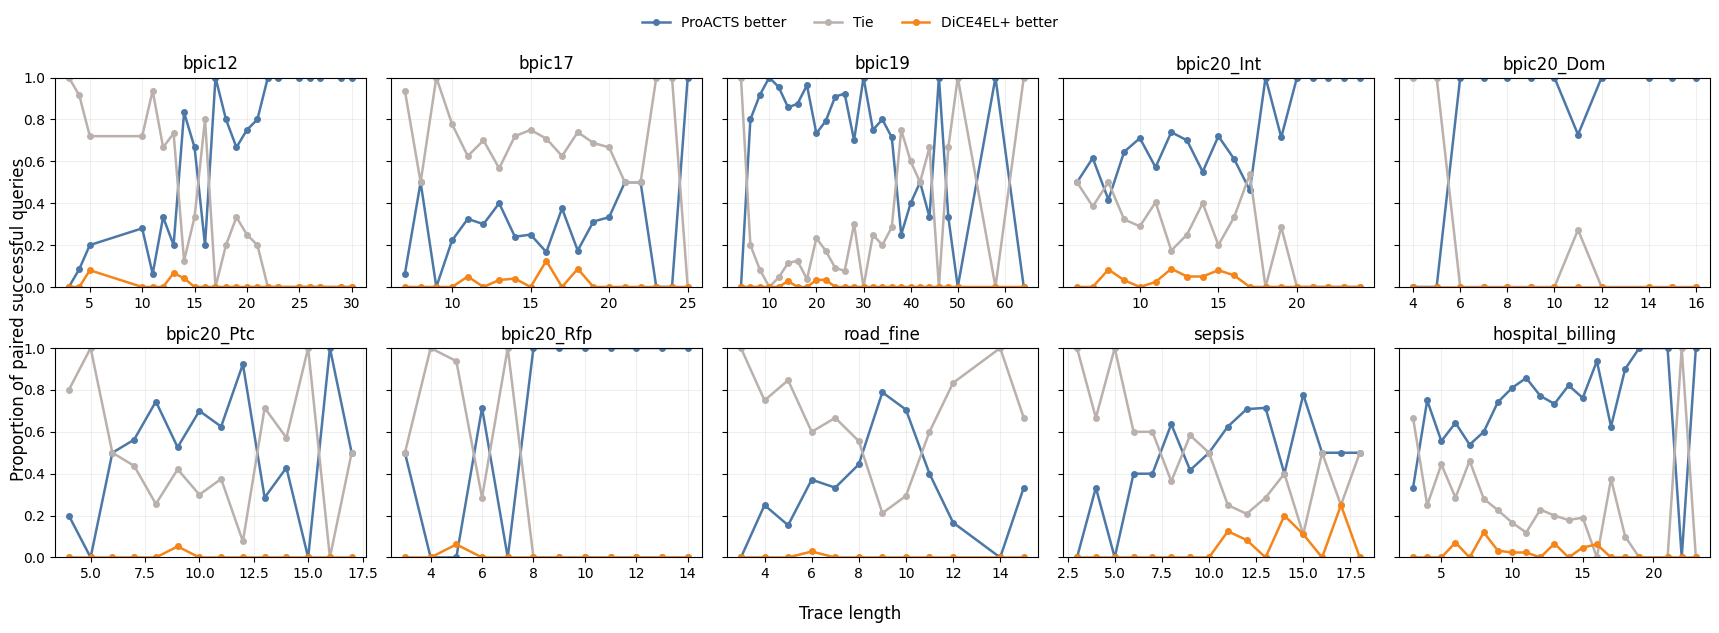

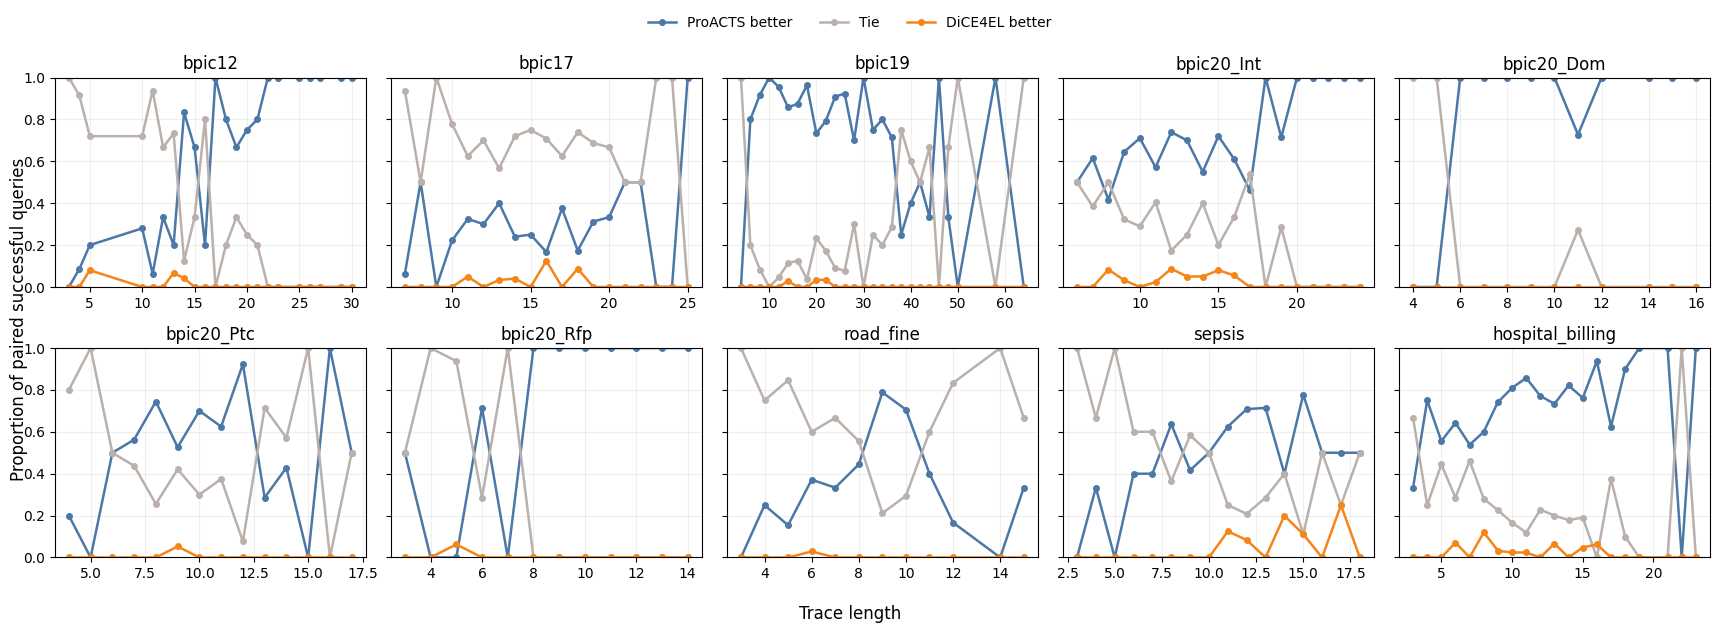

In [8]:
plot_propagation_penalty_outcome_by_trace_length(
    single_summary[
        "propagation_penalty_trace_length"
    ],
    baseline_method="DiCE4EL+",
    output_path=(
        "summary_evaluation/"
        "propagation_penalty_outcome_by_trace_length_"
        "dice4el_plus.pdf"
    ),
    show=True,
)

plot_propagation_penalty_outcome_by_trace_length(
    single_summary[
        "propagation_penalty_trace_length"
    ],
    baseline_method="DiCE4EL",
    output_path=(
        "summary_evaluation/"
        "propagation_penalty_outcome_by_trace_length_"
        "dice4el.pdf"
    ),
    show=True,
)

In [9]:
runtime_paths = {}

for dataset in datasets:

    runtime_paths[
        dataset
    ] = {}

    for seed in seeds:

        runtime_paths[
            dataset
        ][seed] = {
            "ProACTS": (
                f"{dataset}/"
                f"seed_experiments/logs/"
                f"{dataset}-cf_seed{seed}_experiments_ga_output.txt"
            ),
    
            "DiCE": (
                f"{dataset}/"
                f"dice4el/"
                f"seed_experiments/logs/"
                f"{dataset}-cf_seed{seed}_experiments_dice4el_output.txt"
            ),
        }

runtime_table = runtime_table_all_seeds(
    runtime_paths=runtime_paths,
    all_dataset_results=all_results,
    output_path=(
        "summary_evaluation/"
        "runtime_all_seeds.xlsx"
    ),
)

print(
    runtime_table[
        [
            "Dataset",
            "ProACTS Runtime Median [Q1, Q3] (s)",
            "DiCE4EL Runtime Median [Q1, Q3] (s)",
            "DiCE4EL+ Runtime Median [Q1, Q3] (s)",
        ]
    ]
)

bpic12, seed=42: N=312, ProACTS=312, DiCE4EL=312, DiCE4EL+=312, ProACTS total log=608
bpic12, seed=13: N=312, ProACTS=312, DiCE4EL=312, DiCE4EL+=312, ProACTS total log=608
bpic12, seed=777: N=312, ProACTS=312, DiCE4EL=312, DiCE4EL+=312, ProACTS total log=608
bpic17, seed=42: N=379, ProACTS=379, DiCE4EL=379, DiCE4EL+=379, ProACTS total log=762
bpic17, seed=13: N=379, ProACTS=379, DiCE4EL=379, DiCE4EL+=379, ProACTS total log=762
bpic17, seed=777: N=379, ProACTS=379, DiCE4EL=379, DiCE4EL+=379, ProACTS total log=762
bpic19, seed=42: N=467, ProACTS=467, DiCE4EL=467, DiCE4EL+=467, ProACTS total log=950
bpic19, seed=13: N=467, ProACTS=467, DiCE4EL=467, DiCE4EL+=467, ProACTS total log=950
bpic19, seed=777: N=467, ProACTS=467, DiCE4EL=467, DiCE4EL+=467, ProACTS total log=950
bpic20_Int, seed=42: N=352, ProACTS=352, DiCE4EL=352, DiCE4EL+=352, ProACTS total log=721
bpic20_Int, seed=13: N=352, ProACTS=352, DiCE4EL=352, DiCE4EL+=352, ProACTS total log=721
bpic20_Int, seed=777: N=352, ProACTS=352, D

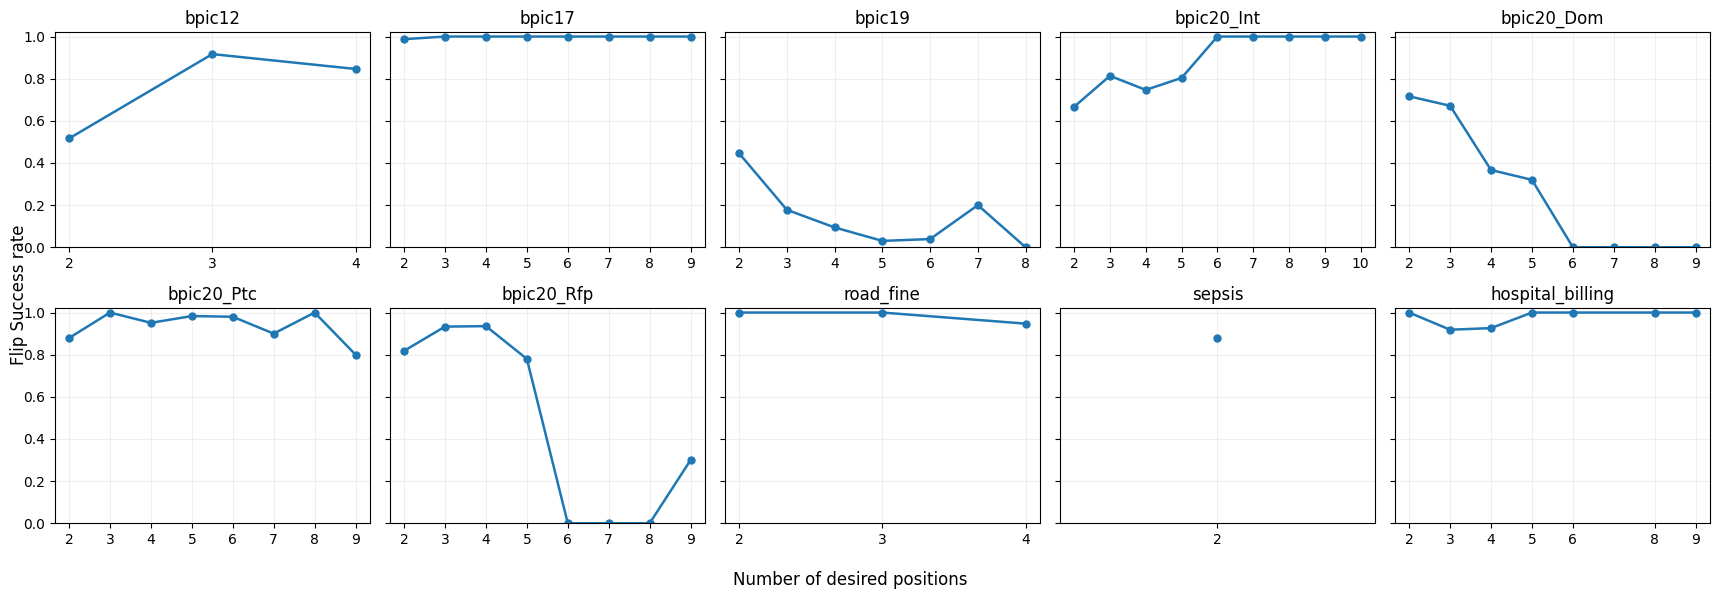

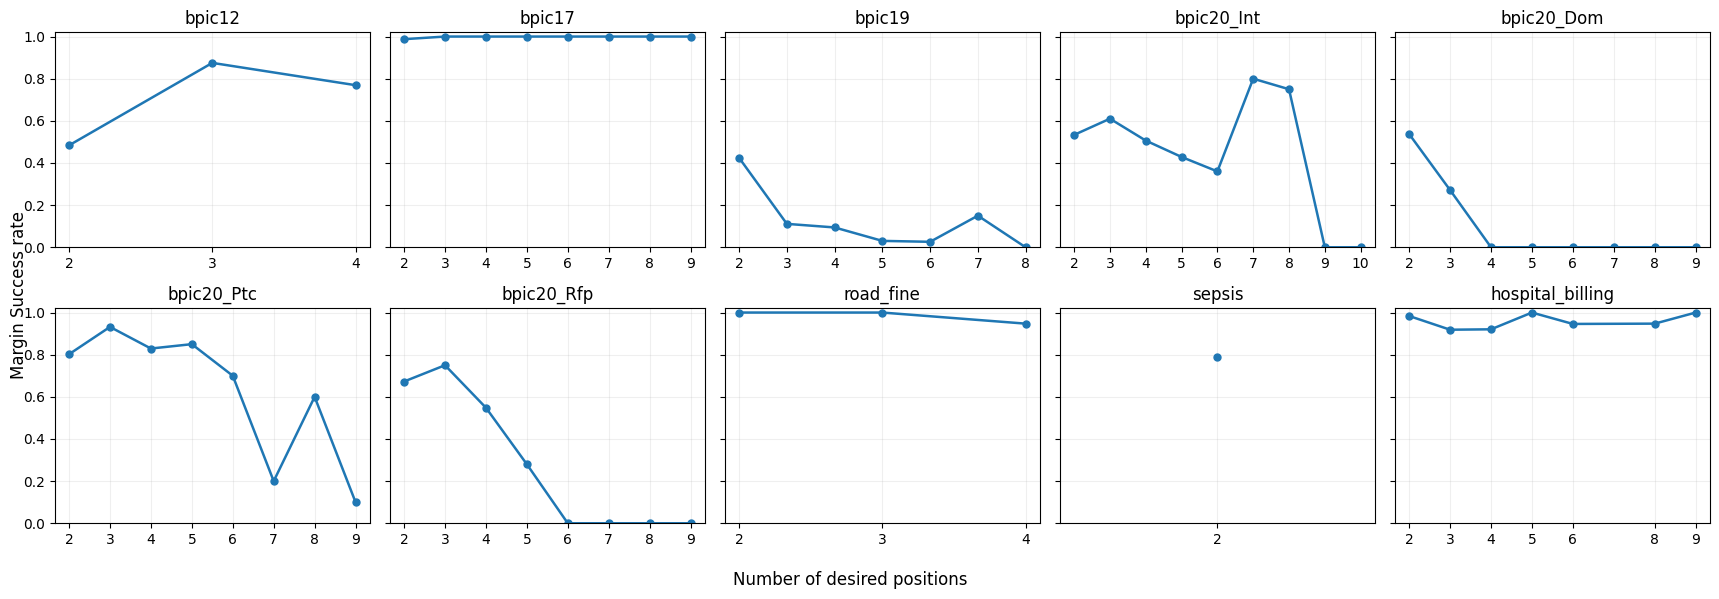

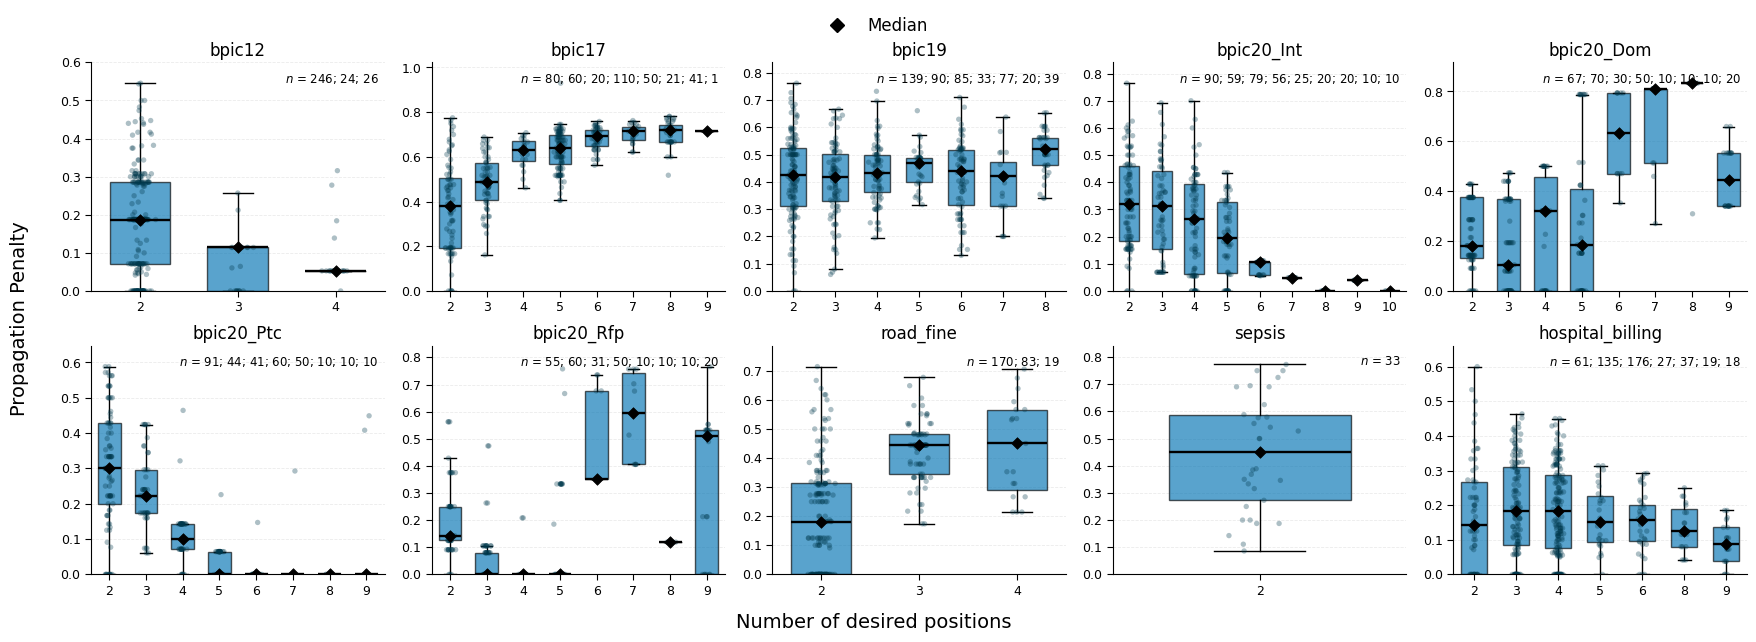

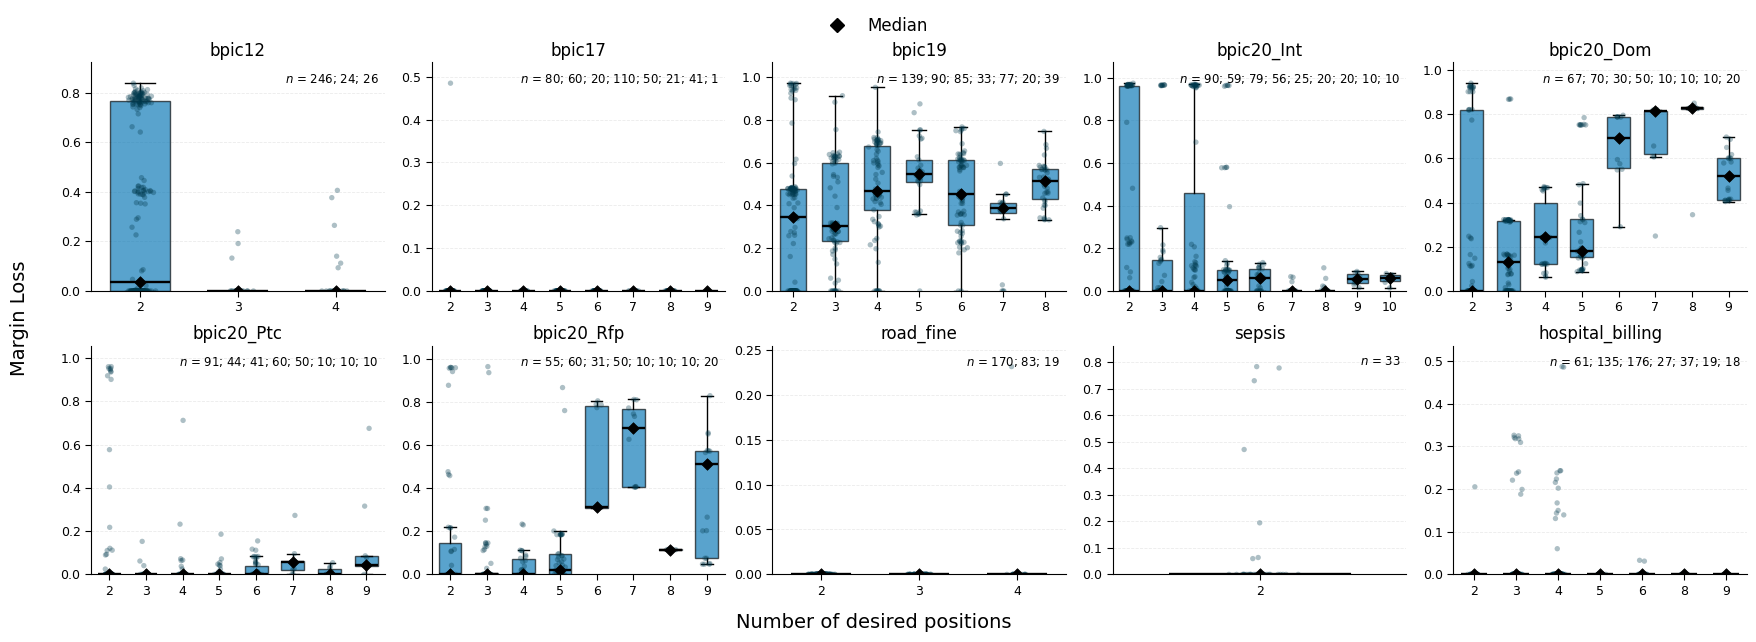

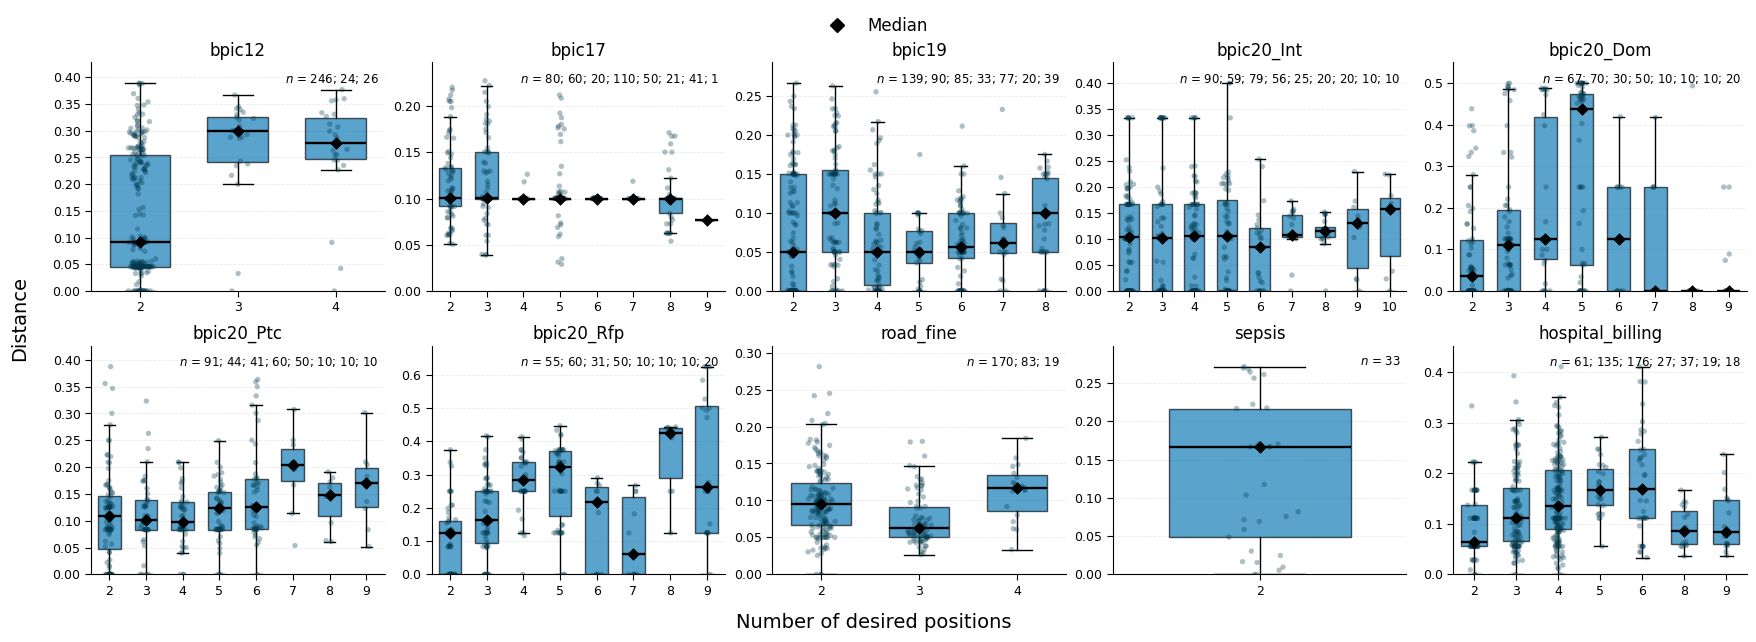

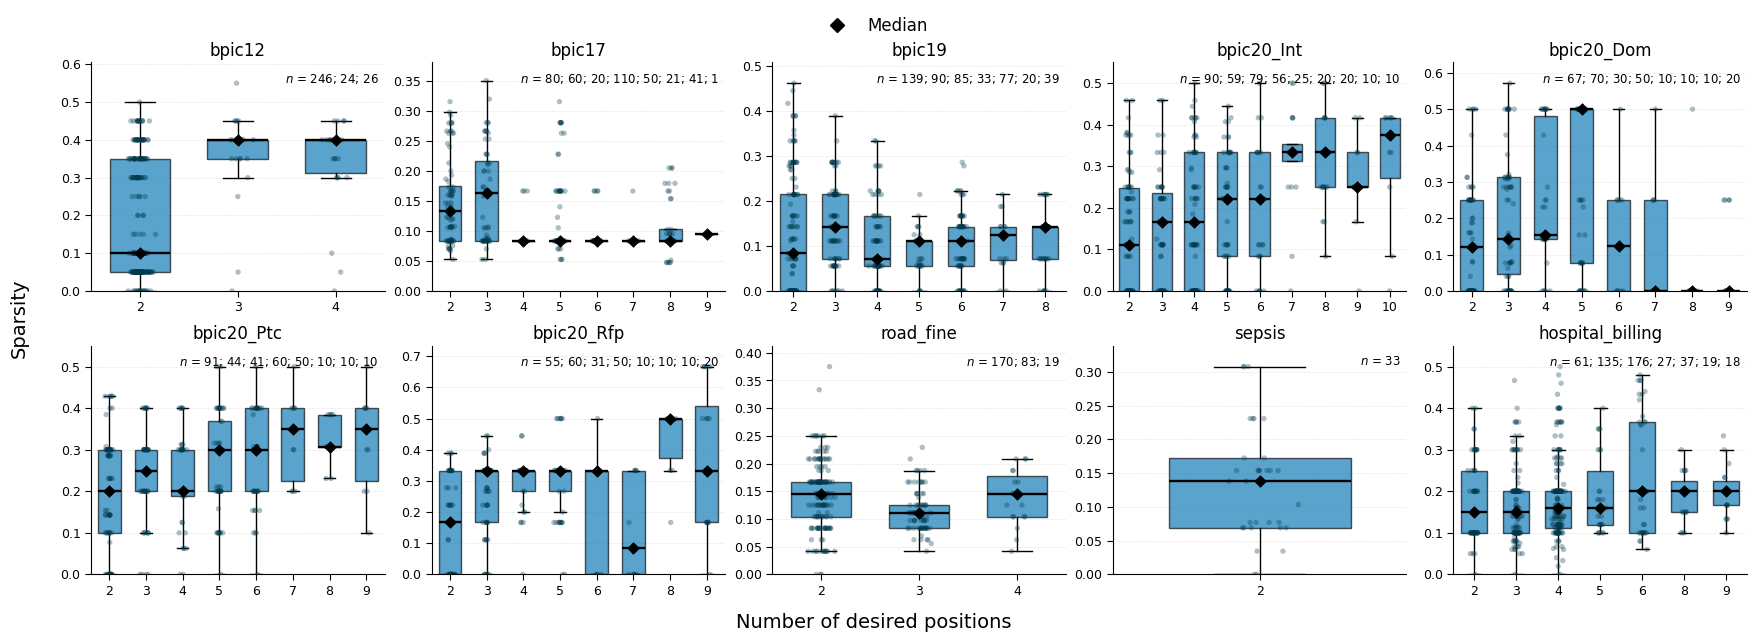

In [10]:
multiple_plots = (
    generate_proacts_multiple_position_plots(
        all_results,
        output_dir="summary_evaluation",
        tolerance=1e-8,
        show=True,
    )
)

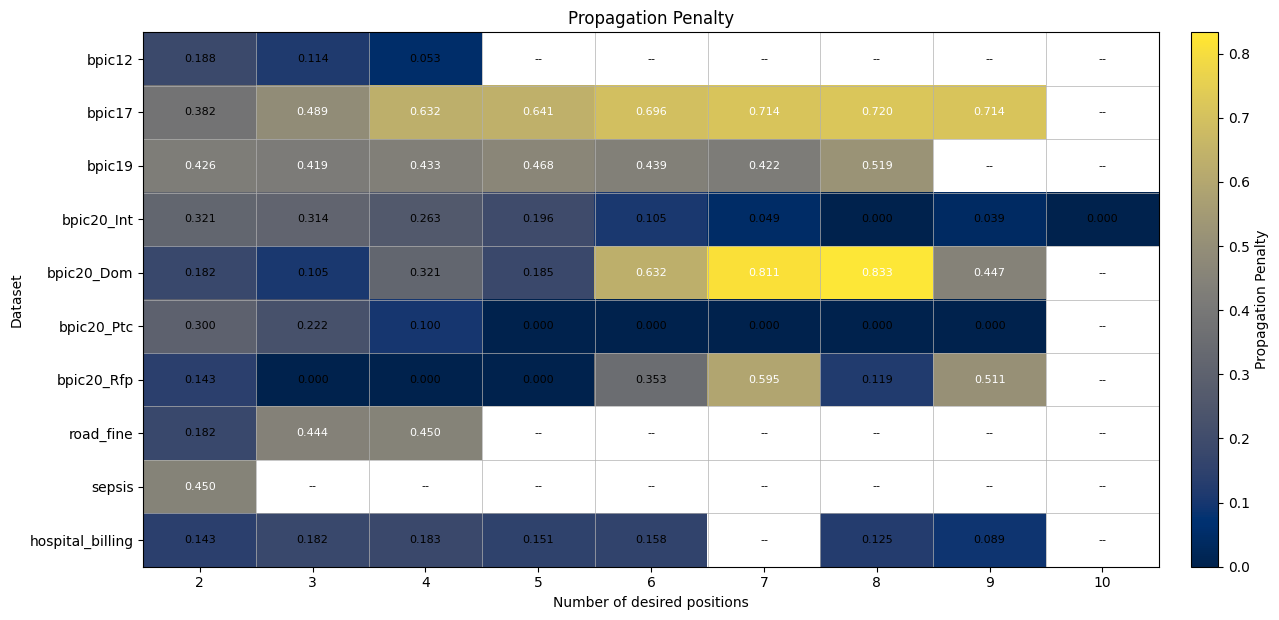

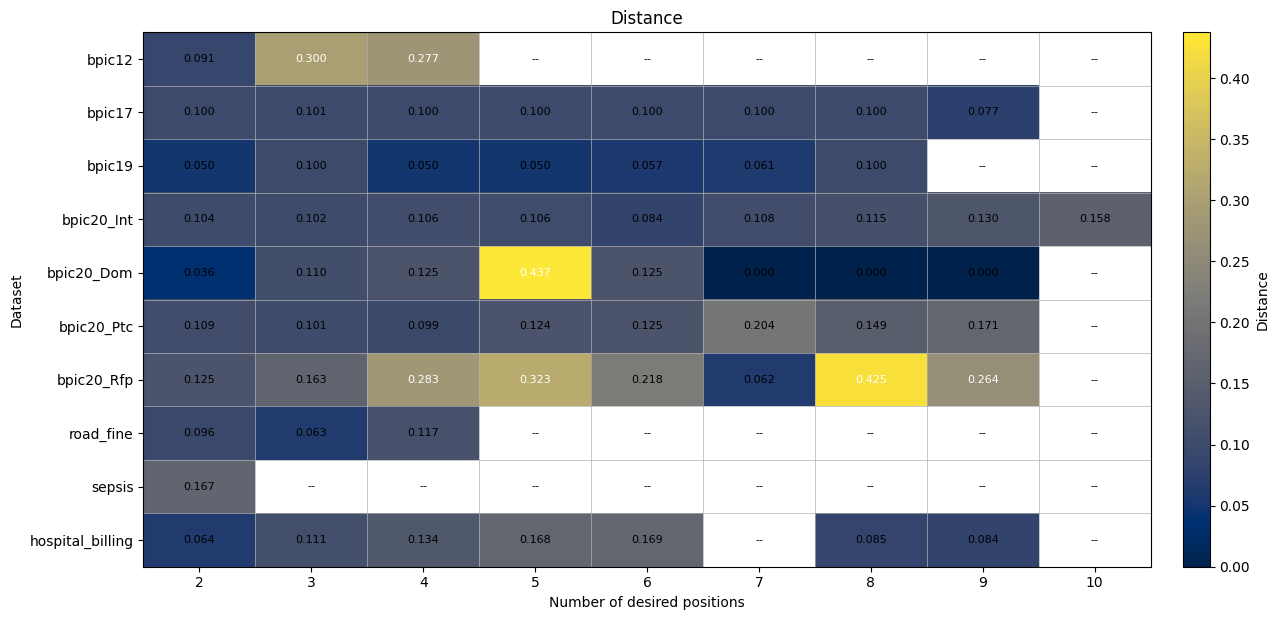

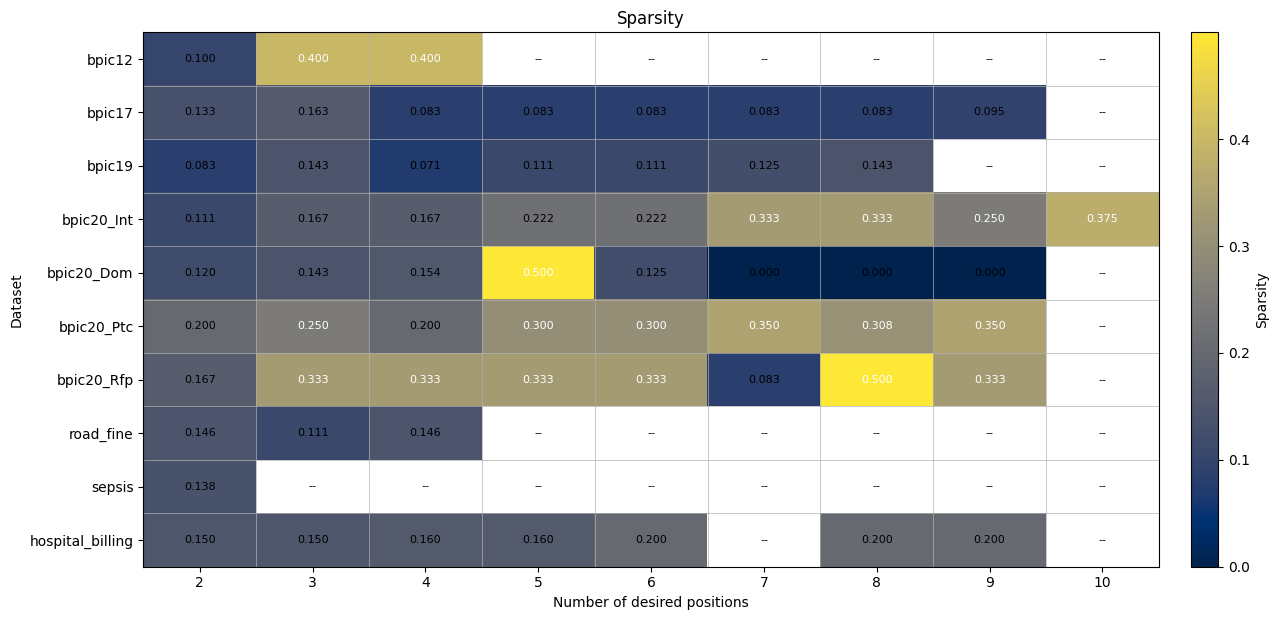

In [11]:
propagation_heatmap = (
    plot_proacts_multiple_metric_heatmap(
        all_results,
        metric="Propagation Penalty",
        aggregation="median",
        output_path=(
            "summary_evaluation/"
            "multiple_propagation_penalty_heatmap.pdf"
        ),
        show=True,
    )
)

distance_heatmap = (
    plot_proacts_multiple_metric_heatmap(
        all_results,
        metric="Distance",
        aggregation="median",
        output_path=(
            "summary_evaluation/"
            "multiple_distance_heatmap.pdf"
        ),
        show=True,
    )
)

sparsity_heatmap = (
    plot_proacts_multiple_metric_heatmap(
        all_results,
        metric="Sparsity",
        aggregation="median",
        output_path=(
            "summary_evaluation/"
            "multiple_sparsity_heatmap.pdf"
        ),
        show=True,
    )
)

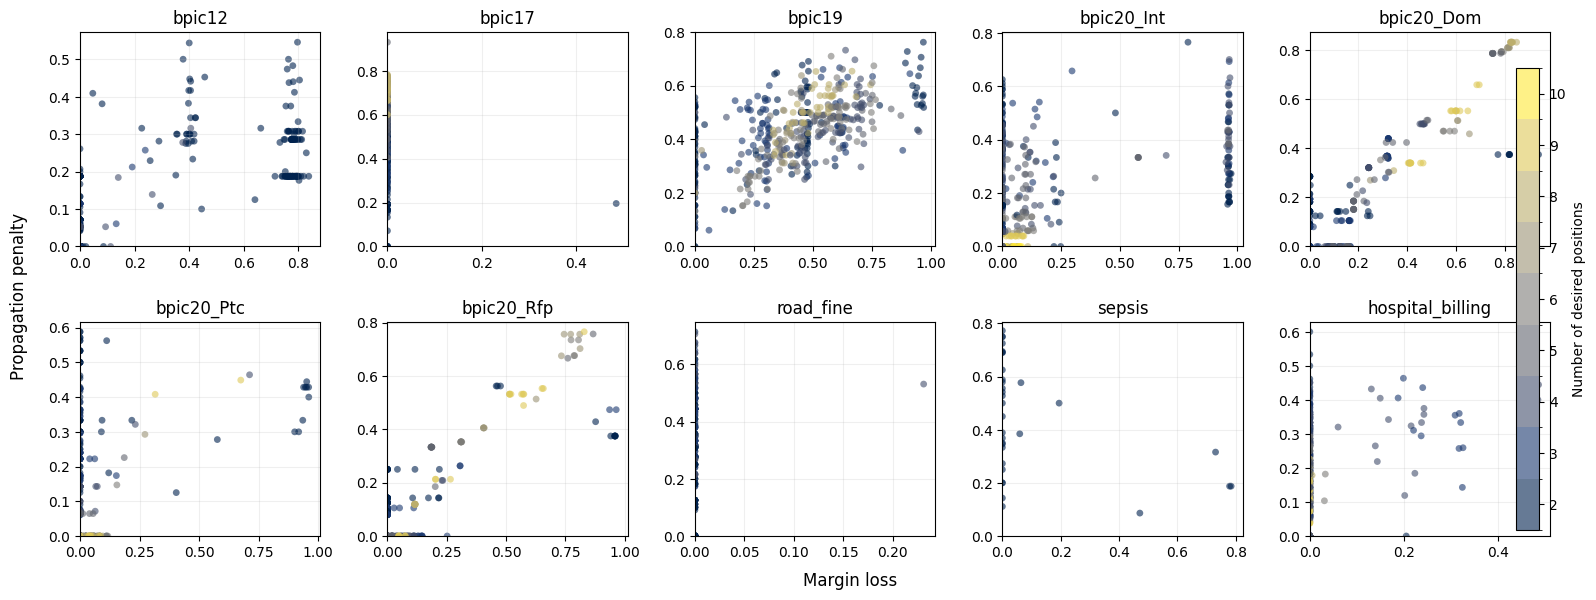

In [12]:
multiple_margin_propagation = (
    plot_proacts_multiple_margin_vs_propagation(
        all_results,
        output_path=(
            "summary_evaluation/"
            "multiple_margin_vs_propagation.pdf"
        ),
        show=True,
    )
)

In [13]:
# ============================================================
# Print
# ============================================================

print(
    "\n=== SINGLE: MAIN RESULTS ==="
)
print(
    single_summary[
        "main_results"
    ]
)

print(
    "\n=== SINGLE: SUCCESS RATES ==="
)
print(
    single_summary[
        "success_rates"
    ]
)

print(
    "\n=== SINGLE: SEED ROBUSTNESS ==="
)
print(
    single_summary[
        "seed_robustness"
    ]
)

print(
    "\n=== SINGLE: RETAINED COUNTS ==="
)
print(
    single_summary[
        "retained_counts"
    ]
)

print(
    "\n=== SINGLE: CONDITIONAL RESULTS ==="
)
print(
    single_summary[
        "conditional_results"
    ]
)

print(
    "\n=== SINGLE: PROCESS VIOLATION TIES ==="
)
print(
    single_summary[
        "propagation_penalty_ties"
    ]
)

print(
    "\n=== SINGLE: PV BY TRACE LENGTH ==="
)
print(
    single_summary[
        "propagation_penalty_trace_length"
    ]
)

print(
    "\n=== MULTIPLE: MAIN RESULTS ==="
)
print(
    multiple_summary[
        "main_results"
    ]
)

print(
    "\n=== MULTIPLE: FLIP RATE ==="
)
print(
    multiple_summary[
        "flip_rate"
    ]
)

print(
    "\n=== MULTIPLE: SEED ROBUSTNESS ==="
)
print(
    multiple_summary[
        "seed_robustness"
    ]
)


=== SINGLE: MAIN RESULTS ===
             Dataset               Metric  N Paired Instances  \
0             bpic12          Margin Loss                 312   
1             bpic12            Flip Loss                 312   
2             bpic12  Propagation Penalty                 312   
3             bpic12             Distance                 312   
4             bpic12             Sparsity                 312   
5             bpic17          Margin Loss                 379   
6             bpic17            Flip Loss                 379   
7             bpic17  Propagation Penalty                 379   
8             bpic17             Distance                 379   
9             bpic17             Sparsity                 379   
10            bpic19          Margin Loss                 467   
11            bpic19            Flip Loss                 467   
12            bpic19  Propagation Penalty                 467   
13            bpic19             Distance                 46

In [14]:
propagation_prevalence = (
    propagation_prevalence_summary(
        all_dataset_results=all_results,
        methods=(
            "ProACTS",
            "DiCE4EL+",
        ),
        tolerance=1e-8,
        output_path=(
            "summary_evaluation/"
            "propagation_prevalence.xlsx"
        ),
    )
)

display(
    propagation_prevalence
)

,Dataset,Method,Success Semantics,N Factual Queries,Target-Successful CFs,Target Success (%),CFs with Propagation,Propagation Prevalence (%),AR Target Failures,AR Target Failure (%),Median Propagation Penalty,"Propagation Penalty [Q1, Q3]"
0,bpic12,ProACTS,AR,312,282,90.384615,176,62.411348,0,0.000000,0.072125,"0.0721248 [0, 0.168894]"
1,bpic12,DiCE4EL+,NA,312,234,75.000000,162,69.230769,58,24.786325,0.171429,"0.171429 [0, 0.393939]"
2,bpic17,ProACTS,AR,379,379,100.000000,355,93.667546,0,0.000000,0.320000,"0.32 [0.0952381, 0.516129]"
3,bpic17,DiCE4EL+,NA,379,363,95.778364,357,98.347107,2,0.550964,0.418605,"0.418605 [0.117647, 0.571429]"
4,bpic19,ProACTS,AR,467,445,95.289079,408,91.685393,0,0.000000,0.342857,"0.342857 [0.255319, 0.421053]"
5,bpic19,DiCE4EL+,NA,467,308,65.952891,283,91.883117,214,69.480519,0.589744,"0.589744 [0.442424, 0.684211]"
6,bpic20_Int,ProACTS,AR,352,341,96.875000,332,97.360704,0,0.000000,0.260870,"0.26087 [0.16, 0.434783]"
7,bpic20_Int,DiCE4EL+,NA,352,300,85.227273,297,99.000000,153,51.000000,0.600000,"0.6 [0.4, 0.76]"
8,bpic20_Dom,ProACTS,AR,152,78,51.315789,65,83.333333,0,0.000000,0.210526,"0.210526 [0.105263, 0.37395]"
9,bpic20_Dom,DiCE4EL+,NA,152,56,36.842105,52,92.857143,44,78.571429,0.789474,"0.789474 [0.714286, 0.789474]"


In [15]:
propagation_prevalence_paper = (
    propagation_prevalence[
        [
            "Dataset",
            "Method",
            "Target-Successful CFs",
            "Propagation Prevalence (%)",
            "AR Target Failure (%)",
        ]
    ]
)

display(
    propagation_prevalence_paper
)

,Dataset,Method,Target-Successful CFs,Propagation Prevalence (%),AR Target Failure (%)
0,bpic12,ProACTS,282,62.411348,0.000000
1,bpic12,DiCE4EL+,234,69.230769,24.786325
2,bpic17,ProACTS,379,93.667546,0.000000
3,bpic17,DiCE4EL+,363,98.347107,0.550964
4,bpic19,ProACTS,445,91.685393,0.000000
5,bpic19,DiCE4EL+,308,91.883117,69.480519
6,bpic20_Int,ProACTS,341,97.360704,0.000000
7,bpic20_Int,DiCE4EL+,300,99.000000,51.000000
8,bpic20_Dom,ProACTS,78,83.333333,0.000000
9,bpic20_Dom,DiCE4EL+,56,92.857143,78.571429


In [16]:
ablation_results = (
    summarize_proacts_propagation_ablation(
        all_dataset_results=all_results,

        ablated_root=".",

        relative_path_template=(
            "{dataset}/"
            "seed_experiments/"
            "Ablated/"
            "generated_experiments_results/"
            "GA_Ablated_single_desired_seed{seed}_"
            "experiment_results.xlsx"
        ),

        alpha=0.05,
        tolerance=1e-8,
        practical_effect_threshold=0.10,

        output_path=(
            "summary_evaluation/"
            "proacts_propagation_ablation.xlsx"
        ),
    )
)

In [17]:
display(
    ablation_results["success"]
)

display(
    ablation_results["conditional"]
)

,Dataset,N Paired,ProACTS Successful,Ablated Successful,ProACTS Success %,Ablated Success %,Both Successful,ProACTS Only,Ablated Only,Neither,Discordant,McNemar Raw p,McNemar Holm-adjusted p,Holm p,Direction,Conclusion
0,bpic12,312,282,283,90.384615,90.705128,279,3,4,26,7,1.000000,1.000000,1.000,ProACTS w/o Prop.,No significant difference
1,bpic17,379,379,379,100.000000,100.000000,379,0,0,0,0,1.000000,1.000000,1.000,Tie,No significant difference
2,bpic19,467,445,444,95.289079,95.074946,440,5,4,18,9,1.000000,1.000000,1.000,ProACTS,No significant difference
3,bpic20_Int,352,341,342,96.875000,97.159091,337,4,5,6,9,1.000000,1.000000,1.000,ProACTS w/o Prop.,No significant difference
4,bpic20_Dom,152,78,73,51.315789,48.026316,70,8,3,71,11,0.226562,1.000000,1.000,ProACTS,No significant difference
5,bpic20_Ptc,166,164,166,98.795181,100.000000,164,0,2,0,2,0.500000,1.000000,1.000,ProACTS w/o Prop.,No significant difference
6,bpic20_Rfp,135,113,100,83.703704,74.074074,97,16,3,19,19,0.004425,0.044250,0.044,ProACTS,ProACTS higher success
7,road_fine,226,226,226,100.000000,100.000000,226,0,0,0,0,1.000000,1.000000,1.000,Tie,No significant difference
8,sepsis,167,150,157,89.820359,94.011976,150,0,7,10,7,0.015625,0.140625,0.141,ProACTS w/o Prop.,No significant difference
9,hospital_billing,370,369,369,99.729730,99.729730,368,1,1,0,2,1.000000,1.000000,1.000,Tie,No significant difference


,Dataset,Metric,N Paired Before Condition,N Retained,Retained %,N Non-Ties,Tie %,ProACTS Mean ± SD,Ablated Mean ± SD,"ProACTS Median [Q1, Q3]",...,Wilcox Raw p,Wilcox Holm-adjusted p,Wilcox Holm p,Pratt Holm p,Z-split Holm p,Rank-Biserial (Non-Ties),Effect,Better Method,Zero-Handling Robustness,Conclusion
0,bpic12,Propagation Penalty,312,279,89.423077,62,77.777778,0.0945221 ± 0.109728,0.131319 ± 0.130206,"0.0689655 [0, 0.157568]",...,1.673758e-11,6.695033e-11,<0.001,<0.001,<0.001,-0.983103,Large,ProACTS,Robust: all significant,ProACTS better
1,bpic12,Margin Loss,312,279,89.423077,29,89.605735,0.0263974 ± 0.0939534,0.0238222 ± 0.086695,"0 [0, 0]",...,1.273999e-01,1.000000e+00,1.000,0.940,1.000,0.324138,Medium,ProACTS w/o Prop.,Robust: none significant,Non-negligible effect; not statistically signi...
2,bpic12,Distance,312,279,89.423077,252,9.677419,0.178744 ± 0.129314,0.157534 ± 0.105284,"0.171397 [0.0564764, 0.279102]",...,1.403185e-06,7.015923e-06,<0.001,<0.001,<0.001,0.350587,Medium,ProACTS w/o Prop.,Robust: all significant,ProACTS w/o Prop. better
3,bpic12,Sparsity,312,279,89.423077,198,29.032258,0.237542 ± 0.170178,0.207793 ± 0.137453,"0.25 [0.0833333, 0.378247]",...,2.815905e-08,1.407952e-07,<0.001,<0.001,<0.001,0.455002,Medium,ProACTS w/o Prop.,Robust: all significant,ProACTS w/o Prop. better
4,bpic17,Propagation Penalty,379,379,100.000000,234,38.258575,0.319406 ± 0.23575,0.592275 ± 0.292566,"0.32 [0.0952381, 0.516129]",...,3.596735e-40,3.237062e-39,<0.001,<0.001,<0.001,-1.000000,Large,ProACTS,Robust: all significant,ProACTS better
5,bpic17,Margin Loss,379,379,100.000000,0,100.000000,0 ± 0,0 ± 0,"0 [0, 0]",...,1.000000e+00,1.000000e+00,1.000,1.000,1.000,0.000000,Negligible,Tie,Robust: none significant,No meaningful evidence of difference
6,bpic17,Distance,379,379,100.000000,379,0.000000,0.142284 ± 0.0603566,0.107238 ± 0.0414669,"0.135499 [0.0894802, 0.192782]",...,5.439985e-29,5.439985e-28,<0.001,<0.001,<0.001,0.662352,Large,ProACTS w/o Prop.,Robust: all significant,ProACTS w/o Prop. better
7,bpic17,Sparsity,379,379,100.000000,338,10.817942,0.196053 ± 0.0897577,0.146662 ± 0.0675367,"0.186667 [0.121212, 0.270833]",...,1.075729e-28,1.075729e-27,<0.001,<0.001,<0.001,0.697492,Large,ProACTS w/o Prop.,Robust: all significant,ProACTS w/o Prop. better
8,bpic19,Propagation Penalty,467,440,94.218415,313,28.863636,0.326089 ± 0.150707,0.448694 ± 0.181532,"0.342857 [0.255126, 0.421053]",...,5.323889e-48,5.323889e-47,<0.001,<0.001,<0.001,-0.949289,Large,ProACTS,Robust: all significant,ProACTS better
9,bpic19,Margin Loss,467,440,94.218415,1,99.772727,0 ± 0,8.128e-06 ± 0.000170496,"0 [0, 0]",...,3.173105e-01,1.000000e+00,1.000,1.000,1.000,-1.000000,Large,ProACTS,Robust: none significant,Non-negligible effect; not statistically signi...


## --- Qualitative Analysis (BPIC20_Dom) ---

In [18]:
import torch

import pandas as pd

from dataclasses import replace
from copy import deepcopy

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from process.engine import ProcessModelConstraintEngine
from process.constraint import ProcessConstraint

from dice4el.scenario.scenario_handler import ScenarioHandler
from dice4el.scenario.scenario_model import ScenarioLSTM, train_ScenarioLSTM, validate_ScenarioLSTM
from dice4el.scenario.scenario_model_wrapper import ScenarioModelWrapper

from ga_search.search import CounterfactualGA

from dice4el.dice4el_config import EventLogDiCEConfig
from dice4el.eventlog_dice import EventLogDiCE
from dice4el.eventlog_dice_optimized import EventLogDiCEOptimized

### --- Load Datasets, Configurations and Models ---

In [19]:
set_seed(seed=42)

In [20]:
df = pd.read_excel(
    "../data/bpic20_Dom.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "org:resource": "string",
        "org:role": "string",
        "case:Amount": "float32",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [21]:
df.head(20)

,case:concept:name,time:timestamp,case:Amount,concept:name,org:resource,org:role,time_delta
0,declaration 100000,2018-01-30 09:20:07,600.844116,Declaration SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0
1,declaration 100000,2018-02-07 09:58:46,600.844116,Declaration APPROVED by ADMINISTRATION,STAFF MEMBER,ADMINISTRATION,693519.0
2,declaration 100000,2018-02-08 10:59:05,600.844116,Declaration FINAL_APPROVED by SUPERVISOR,STAFF MEMBER,SUPERVISOR,90019.0
3,declaration 100000,2018-02-09 12:42:49,600.844116,Request Payment,SYSTEM,UNDEFINED,92624.0
4,declaration 100000,2018-02-12 17:31:20,600.844116,Payment Handled,SYSTEM,UNDEFINED,276511.0
5,declaration 100005,2018-01-30 09:38:54,35.133686,Declaration SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0
6,declaration 100005,2018-01-30 09:38:57,35.133686,Declaration APPROVED by ADMINISTRATION,STAFF MEMBER,ADMINISTRATION,3.0
7,declaration 100005,2018-01-30 10:04:10,35.133686,Declaration FINAL_APPROVED by SUPERVISOR,STAFF MEMBER,SUPERVISOR,1513.0
8,declaration 100005,2018-01-31 12:45:18,35.133686,Request Payment,SYSTEM,UNDEFINED,96068.0
9,declaration 100005,2018-02-01 17:31:17,35.133686,Payment Handled,SYSTEM,UNDEFINED,103559.0


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
feature_config = FeatureConfig.load(
    path = "bpic20_Dom/pretrained_models/"
)

In [24]:
simple_feature_specs = deepcopy(feature_config.feature_specs)
simple_feature_specs["time_delta"]["vary"] = False

feature_config = replace(
    feature_config,
    feature_specs=simple_feature_specs,
)

In [25]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['case:Amount', 'concept:name', 'org:resource', 'org:role', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
time_delta                     continuous     event    no     [2.00, 284911.00]                        42289.5000 quantile_derived    
case:Amount                    continuous     case     yes    [6.91, 219.03]                           25.3885    quantile_derived    
org:resource                   categorical    event    yes    ['STAFF MEMBER', 'SYSTEM']               N/A        data_derived        
org:role                       categorical    event    ye

In [26]:
preprocessor_artifacts = PreprocessorArtifacts.load(
    path = "bpic20_Dom/pretrained_models/"
)

model = ProcessLSTM.load(
    path = "bpic20_Dom/pretrained_models/"
)

model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

In [27]:
scenario_handler =  ScenarioHandler(
    feature_config=feature_config,
    preprocessor_artifacts=preprocessor_artifacts
)

scenario_model = ScenarioLSTM.load(
    "bpic20_Dom/dice4el/pretrained_models/"
)

scenario_model_wrapper = ScenarioModelWrapper(
    scenario_model=scenario_model,
    scenario_handler=scenario_handler,
    device=device
)

In [28]:
engine = ProcessModelConstraintEngine.load(
    path = "bpic20_Dom/pretrained_models/"
)

print(engine.parallel_sets)
print(engine.branching_sets)

[]
[{'Declaration REJECTED by BUDGET OWNER', 'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by ADMINISTRATION', 'Declaration APPROVED by BUDGET OWNER', 'Declaration REJECTED by MISSING', 'Declaration REJECTED by PRE_APPROVER', 'Declaration APPROVED by ADMINISTRATION', 'Declaration FOR_APPROVAL by SUPERVISOR', 'Declaration SUBMITTED by EMPLOYEE', 'Declaration REJECTED by SUPERVISOR', 'Declaration APPROVED by PRE_APPROVER'}, {'Declaration REJECTED by BUDGET OWNER', 'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by ADMINISTRATION', 'Declaration REJECTED by MISSING', 'Declaration REJECTED by PRE_APPROVER', 'Declaration FOR_APPROVAL by SUPERVISOR', 'Declaration REJECTED by SUPERVISOR'}, {'Declaration REJECTED by MISSING', 'Declaration REJECTED by BUDGET OWNER', 'Declaration FOR_APPROVAL by SUPERVISOR'}, {'Declaration REJECTED by PRE_APPROVER', 'Declaration REJECTED by ADMINISTRATION', 'Declaration REJECTED by SUPERVISOR'}]


In [29]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
    output_population_size=1,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [30]:
dice4el_config = EventLogDiCEConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
dice4el_config.validate()

dice4el = EventLogDiCE(
    dice4el_config=dice4el_config,
    next_event_model_wrapper=model_wrapper,
    scenario_model_wrapper=scenario_model_wrapper,
)

dice4el_optimized = EventLogDiCEOptimized(
    dice4el_config=dice4el_config,
    next_event_model_wrapper=model_wrapper,
    scenario_model_wrapper=scenario_model_wrapper,
)

### --- Counterfactual Example 1 ---

In [31]:
trace_df = df[df['case:concept:name'] == "declaration 109569"].sort_values(by='time:timestamp').iloc[:2].copy()
trace_length = len(trace_df)
trace_activities = tuple(trace_df[feature_config.activity_feature].astype(str).tolist())

print(trace_df)
print(trace_length)
print(trace_activities)

trace_arr = df_to_sequence_array(
    df=trace_df,
    case_id_field='case:concept:name',
    sort_field='time:timestamp',
    feature_config=feature_config,
    prefix_len=trace_length,
)[0]

       case:concept:name      time:timestamp  case:Amount  \
9501  declaration 109569 2018-01-14 16:51:02          0.0   
9502  declaration 109569 2018-01-14 16:51:11          0.0   

                                concept:name  org:resource        org:role  \
9501       Declaration SUBMITTED by EMPLOYEE  STAFF MEMBER        EMPLOYEE   
9502  Declaration REJECTED by ADMINISTRATION  STAFF MEMBER  ADMINISTRATION   

      time_delta  
9501         0.0  
9502         9.0  
2
('Declaration SUBMITTED by EMPLOYEE', 'Declaration REJECTED by ADMINISTRATION')


In [32]:
train_arr = df_to_sequence_array(
    df=df,
    case_id_field='case:concept:name',
    sort_field='time:timestamp',
    feature_config=feature_config,
    prefix_len=trace_length,
)

In [33]:
target_sequence = [
    'Declaration SUBMITTED by EMPLOYEE', 'Declaration APPROVED by ADMINISTRATION',
]

trace_sequences = df.groupby('case:concept:name')['concept:name'].apply(list)

matching_case_ids = trace_sequences[
    trace_sequences.apply(lambda x: x[:trace_length] == target_sequence)
].index.tolist()

matching_traces_df = df[df['case:concept:name'].isin(matching_case_ids)]

conformant_arr = df_to_sequence_array(
    df=matching_traces_df,
    case_id_field='case:concept:name',
    sort_field='time:timestamp',
    feature_config=feature_config,
    prefix_len=trace_length,
)

In [34]:
flexible_constraints = engine.generate_flexible_constraints(trace_activities)
print("Flexible Constraints:", flexible_constraints)

change_allowed_positions = list(range(trace_length-1))
user_rules = {
    ("Declaration REJECTED by ADMINISTRATION", 1): {"Declaration APPROVED by ADMINISTRATION"},
}

desired_constraints = engine.generate_desired_constraints(
    trace_activities=trace_activities,
    user_specs=user_rules
)
print("Desired Constraints: ", desired_constraints)
print("Change Allowed Positions: ", change_allowed_positions)

Flexible Constraints: No Constraints
Desired Constraints:  1:1 - [Declaration APPROVED by ADMINISTRATION]
Change Allowed Positions:  [0]


In [35]:
cf_GA_1 = cf_GA.search(
    trace=trace_arr,
    train_arr=train_arr,
    conformant_arr=conformant_arr,
    change_allowed_positions=change_allowed_positions,
    desired_constraints=desired_constraints,
    flexible_constraints=flexible_constraints,
    output_path=(
        f"./summary_evaluation/counterfactuals/declaration 109569_1_GA.xlsx"
    )
)

Early stopping at generation 53: no improvement for 50 generations. Best fitness = 0.387140
Time taken GA loop: 2.264086 seconds
Time taken for fitness calculation: 0.009606 seconds
=== Evaluation metrics of counterfactuals ===
{'DISTANCE': 0.05380619317293167, 'CONT_DISTANCE': 0.10761238634586334, 'CAT_DISTANCE': 0.0, 'SPARSITY': 0.3333333322222222, 'PROCESS_VIOLATION': 0.0, 'MARGIN_LOSS': 0.0, 'MARGIN_LOSS_NA': 0.0, 'MARGIN_LOSS_FLIPPED': 0.0, 'MARGIN_LOSS_NA_FLIPPED': 0.0, 'FITNESS': 0.3871395253951539, 'IMPLAUSIBILITY': 0.0, 'DIVERSITY': 0.0}
Saved results to ./summary_evaluation/counterfactuals/declaration 109569_1_GA.xlsx


In [36]:
cf_dice4el_1 = dice4el.search(
    trace=trace_arr,
    train_arr=train_arr,
    conformant_arr=conformant_arr,
    change_allowed_positions=change_allowed_positions,
    desired_constraints=desired_constraints,
    flexible_constraints=flexible_constraints,
    output_path=(
        f"./summary_evaluation/counterfactuals/declaration 109569_1_DiCE4EL.xlsx"
    )
)

[20] soft_total=0.0248 soft_margin=0.0000 soft_scenario=0.0021 soft_distance=0.0226 soft_cat=0.0000 | projected_total=0.0248 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0023 projected_distance=0.0225 projected_cat=0.0000
[40] soft_total=0.0228 soft_margin=0.0000 soft_scenario=0.0018 soft_distance=0.0210 soft_cat=0.0000 | projected_total=0.0227 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0018 projected_distance=0.0209 projected_cat=0.0000
[60] soft_total=0.0192 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0181 soft_cat=0.0000 | projected_total=0.0189 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0011 projected_distance=0.0178 projected_cat=0.0000
[80] soft_total=0.0179 soft_margin=0.0000 soft_scenario=0.0009 soft_distance=0.0170 soft_cat=0.0000 | projected_total=0.0179 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0010 projected_distance=0.0169 proje

In [37]:
cf_dice4el_optim_1 = dice4el.search(
    trace=trace_arr,
    train_arr=train_arr,
    conformant_arr=conformant_arr,
    change_allowed_positions=change_allowed_positions,
    desired_constraints=desired_constraints,
    flexible_constraints=flexible_constraints,
    output_path=(
        f"./summary_evaluation/counterfactuals/declaration 109569_1_DiCE4ELOptimized.xlsx"
    )
)

[20] soft_total=0.0248 soft_margin=0.0000 soft_scenario=0.0021 soft_distance=0.0226 soft_cat=0.0000 | projected_total=0.0248 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0023 projected_distance=0.0225 projected_cat=0.0000
[40] soft_total=0.0228 soft_margin=0.0000 soft_scenario=0.0018 soft_distance=0.0210 soft_cat=0.0000 | projected_total=0.0227 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0018 projected_distance=0.0209 projected_cat=0.0000
[60] soft_total=0.0192 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0181 soft_cat=0.0000 | projected_total=0.0189 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0011 projected_distance=0.0178 projected_cat=0.0000
[80] soft_total=0.0179 soft_margin=0.0000 soft_scenario=0.0009 soft_distance=0.0170 soft_cat=0.0000 | projected_total=0.0179 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0010 projected_distance=0.0169 proje

### --- Counterfactual Example 2 ---

In [38]:
trace_df = df[df['case:concept:name'] == "declaration 109569"].sort_values(by='time:timestamp').iloc[:-1].copy()
trace_length = len(trace_df)
trace_activities = tuple(trace_df[feature_config.activity_feature].astype(str).tolist())

print(trace_df)
print(trace_length)
print(trace_activities)

trace_arr = df_to_sequence_array(
    df=trace_df,
    case_id_field='case:concept:name',
    sort_field='time:timestamp',
    feature_config=feature_config,
    prefix_len=trace_length,
)[0]

       case:concept:name      time:timestamp  case:Amount  \
9501  declaration 109569 2018-01-14 16:51:02          0.0   
9502  declaration 109569 2018-01-14 16:51:11          0.0   
9503  declaration 109569 2018-01-15 15:35:45          0.0   
9504  declaration 109569 2018-01-21 16:19:33          0.0   
9505  declaration 109569 2018-01-21 16:19:44          0.0   

                                concept:name  org:resource        org:role  \
9501       Declaration SUBMITTED by EMPLOYEE  STAFF MEMBER        EMPLOYEE   
9502  Declaration REJECTED by ADMINISTRATION  STAFF MEMBER  ADMINISTRATION   
9503        Declaration REJECTED by EMPLOYEE  STAFF MEMBER        EMPLOYEE   
9504       Declaration SUBMITTED by EMPLOYEE  STAFF MEMBER        EMPLOYEE   
9505  Declaration REJECTED by ADMINISTRATION  STAFF MEMBER  ADMINISTRATION   

      time_delta  
9501         0.0  
9502         9.0  
9503     81874.0  
9504    521028.0  
9505        11.0  
5
('Declaration SUBMITTED by EMPLOYEE', 'Declarati

In [39]:
train_arr = df_to_sequence_array(
    df=df,
    case_id_field='case:concept:name',
    sort_field='time:timestamp',
    feature_config=feature_config,
    prefix_len=trace_length,
)

In [40]:
target_sequence = [
    'Declaration SUBMITTED by EMPLOYEE', 'Declaration REJECTED by ADMINISTRATION', 'Declaration REJECTED by EMPLOYEE', 
    'Declaration SUBMITTED by EMPLOYEE', 'Declaration APPROVED by ADMINISTRATION',
]

trace_sequences = df.groupby('case:concept:name')['concept:name'].apply(list)

matching_case_ids = trace_sequences[
    trace_sequences.apply(
        lambda x: x[:trace_length] == target_sequence[:trace_length]
    )
].index.tolist()

matching_traces_df = df[df['case:concept:name'].isin(matching_case_ids)]

conformant_arr = df_to_sequence_array(
    df=matching_traces_df,
    case_id_field='case:concept:name',
    sort_field='time:timestamp',
    feature_config=feature_config,
    prefix_len=trace_length,
)

In [41]:
flexible_constraints = engine.generate_flexible_constraints(trace_activities)
print("Flexible Constraints:", flexible_constraints)

change_allowed_positions = list(range(trace_length-1))
user_rules = {
    ("Declaration REJECTED by ADMINISTRATION", 2): {"Declaration APPROVED by ADMINISTRATION"},
}

desired_constraints = engine.generate_desired_constraints(
    trace_activities=trace_activities,
    user_specs=user_rules
)
print("Desired Constraints: ", desired_constraints)
print("Change Allowed Positions: ", change_allowed_positions)

Flexible Constraints: No Constraints
Desired Constraints:  4:4 - [Declaration APPROVED by ADMINISTRATION]
Change Allowed Positions:  [0, 1, 2, 3]


In [42]:
cf_GA_2 = cf_GA.search(
    trace=trace_arr,
    train_arr=train_arr,
    conformant_arr=conformant_arr,
    change_allowed_positions=change_allowed_positions,
    desired_constraints=desired_constraints,
    flexible_constraints=flexible_constraints,
    output_path=(
        f"./summary_evaluation/counterfactuals/declaration 109569_2_GA.xlsx"
    )
)

Early stopping at generation 103: no improvement for 50 generations. Best fitness = 0.779447
Time taken GA loop: 7.081828 seconds
Time taken for fitness calculation: 0.012438 seconds
=== Evaluation metrics of counterfactuals ===
{'DISTANCE': 0.5572251974755096, 'CONT_DISTANCE': 0.9894503951072693, 'CAT_DISTANCE': 0.12499999984374999, 'SPARSITY': 0.2222222219753086, 'PROCESS_VIOLATION': 0.0, 'MARGIN_LOSS': 0.0, 'MARGIN_LOSS_NA': 0.0, 'MARGIN_LOSS_FLIPPED': 0.0, 'MARGIN_LOSS_NA_FLIPPED': 0.0, 'FITNESS': 0.7794474194508182, 'IMPLAUSIBILITY': 0.06371008360292763, 'DIVERSITY': 0.0}
Saved results to ./summary_evaluation/counterfactuals/declaration 109569_2_GA.xlsx


In [43]:
cf_dice4el_2 = dice4el.search(
    trace=trace_arr,
    train_arr=train_arr,
    conformant_arr=conformant_arr,
    change_allowed_positions=change_allowed_positions,
    desired_constraints=desired_constraints,
    flexible_constraints=flexible_constraints,
    output_path=(
        f"./summary_evaluation/counterfactuals/declaration 109569_2_DiCE4EL.xlsx"
    )
)

[20] soft_total=0.0852 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0837 soft_cat=0.0003 | projected_total=0.0821 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0011 projected_distance=0.0810 projected_cat=0.0000
[40] soft_total=0.0806 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0795 soft_cat=0.0000 | projected_total=0.0805 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0012 projected_distance=0.0793 projected_cat=0.0000
[60] soft_total=0.0801 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0790 soft_cat=0.0000 | projected_total=0.0801 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0012 projected_distance=0.0789 projected_cat=0.0000
[80] soft_total=0.0795 soft_margin=0.0000 soft_scenario=0.0010 soft_distance=0.0785 soft_cat=0.0000 | projected_total=0.0795 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0011 projected_distance=0.0784 proje

In [44]:
cf_dice4el_optim_2 = dice4el.search(
    trace=trace_arr,
    train_arr=train_arr,
    conformant_arr=conformant_arr,
    change_allowed_positions=change_allowed_positions,
    desired_constraints=desired_constraints,
    flexible_constraints=flexible_constraints,
    output_path=(
        f"./summary_evaluation/counterfactuals/declaration 109569_2_DiCE4ELOptimized.xlsx"
    )
)

[20] soft_total=0.0852 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0837 soft_cat=0.0003 | projected_total=0.0821 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0011 projected_distance=0.0810 projected_cat=0.0000
[40] soft_total=0.0806 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0795 soft_cat=0.0000 | projected_total=0.0805 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0012 projected_distance=0.0793 projected_cat=0.0000
[60] soft_total=0.0801 soft_margin=0.0000 soft_scenario=0.0011 soft_distance=0.0790 soft_cat=0.0000 | projected_total=0.0801 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0012 projected_distance=0.0789 projected_cat=0.0000
[80] soft_total=0.0795 soft_margin=0.0000 soft_scenario=0.0010 soft_distance=0.0785 soft_cat=0.0000 | projected_total=0.0795 projected_margin=0.0000 projected_margin_flipped=0.0000 projected_scenario=0.0011 projected_distance=0.0784 proje